# Нарративы престижности и доступности высшего образования в московских вузах (на примере публикаций в новостных сообществах ВКонтакте за 2020-2025 гг.)


# Улучшенные модели для анализа содержательного отклика в комментариях

## Логика ноутбука

Данный ноутбук является продолжением baseline-этапа. Он проверяет, улучшает ли классификационное выделение публикаций с высоким содержательным откликом в комментариях использование более сложных моделей. 

Исследовательская логика сохраняется, рассматриваются публикации сообществ московских вузов в соцсети ВКонтакте, эти публикации классифицируются через два типа медианарратива (нарратив престижности и социальной доступности высшего образования), комментарии к публикациям рассматриваются в качестве отдельного слоя данных, отражающих пользовательскую реакцию на контент сообщества.


Ноутбук решает следующие задачи:  
1. Загружает корпус публикаций университетских сообществ ВКонтакте, имеющих слой публикаций с комментариями.
2. Создает новые признаки: календарные, текстовые и поведенческие.
3. Отделяет содержательные комментарии от механических, ритуальных и конкурсных реакций.
4. Формирует таргет высокого содержательного отклика в комментариях.
5. Сравнивает несколько моделей: Dummy, LogisticRegression + TF-IDF, RandomForest, HistGradientBoosting, XGBoost, CatBoost, Word2Vec/FastText.
6. Сравнивает MiniLM и E5 как современные мультиязычные эмбеддинги в рамках проверки семантического сигнала публикаций.
7. Формирует таблицы сравнения работы моделей.

## Импорт библиотек и настройка параметров отображения элементов

In [37]:
import numpy as np
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import re
import math
from IPython.display import display, Markdown
from collections import Counter
import emoji
from tqdm import tqdm
from nltk.corpus import stopwords

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from gensim.models import Word2Vec, FastText

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 80)
pd.set_option('display.max_colwidth', 150)
pd.set_option('display.float_format', lambda x:f'{x:,.2f}')

sns.set_theme(style='whitegrid', context='notebook', font_scale=1.05)
sns.set_palette('pastel')
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.family'] = 'Times New Roman'

## Загрузка данных и создание признаков

In [38]:
comms = pd.read_csv('/Users/ekaterinamalkova/Desktop/vkr_analysis/data/data_with_comments.csv')
comms = comms.drop(columns=['Unnamed: 0'])

display(comms.shape)
display(comms[['post_id', 'date', 'source_nickname', 'likes', 'comments_count', 'reposts', 'views']].head())

(99280, 11)

,post_id,date,source_nickname,likes,comments_count,reposts,views
0,77019,2025-12-29,hse.csv,16,1,4,3546
1,76983,2025-12-23,hse.csv,57,2,1,12237
2,76975,2025-12-22,hse.csv,31,1,2,7496
3,76962,2025-12-19,hse.csv,46,1,5,6359
4,76950,2025-12-18,hse.csv,28,2,9,9664


In [39]:
# создаем признаки года, месяца, квартала, дня недели и времени года
# создаем признаки вовлеченности

comms['date'] = pd.to_datetime(comms['date'])
    
for col in ['likes', 'comments_count', 'reposts', 'views']:
    comms[col] = pd.to_numeric(comms[col])

comms['likes_p1000_views'] = comms['likes'] / comms['views'] * 1000
comms['comments_p1000_views'] = comms['comments_count'] / comms['views'] * 1000
comms['reposts_p1000_views'] = comms['reposts'] / comms['views'] * 1000
comms['log_views'] = np.log1p(comms['views'])
comms['log_likes'] = np.log1p(comms['likes'])
comms['log_comments_count'] = np.log1p(comms['comments_count'])
comms['log_reposts'] = np.log1p(comms['reposts'])
        

comms['year'] = comms['date'].dt.year.astype('Int64')
comms['month'] = comms['date'].dt.month.astype('Int64')
comms['quarter'] = comms['date'].dt.quarter
comms['weekday'] = comms['date'].dt.day_name()
comms['season'] = np.select([comms['month'].isin([12, 1, 2]),
                              comms['month'].isin([3, 4, 5]),
                              comms['month'].isin([6, 7, 8]),
                              comms['month'].isin([9, 10, 11])],
                             ['winter', 'spring', 'summer', 'autumn'], default='unknown')
display(comms[['date', 'year',
       'month', 'quarter', 'weekday', 'season',
       'likes_p1000_views', 'comments_p1000_views', 'reposts_p1000_views'
       ]].head())

,date,year,month,quarter,weekday,season,likes_p1000_views,comments_p1000_views,reposts_p1000_views
0,2025-12-29,2025,12,4,Monday,winter,4.51,0.28,1.13
1,2025-12-23,2025,12,4,Tuesday,winter,4.66,0.16,0.08
2,2025-12-22,2025,12,4,Monday,winter,4.14,0.13,0.27
3,2025-12-19,2025,12,4,Friday,winter,7.23,0.16,0.79
4,2025-12-18,2025,12,4,Thursday,winter,2.90,0.21,0.93


## Далее поработаем над текстом: текстами публикаций и комментариев

### Вспомогательные функции для текстовых представлений

In [40]:
# разделяет комментарии по границе ' | '
def split_comms(text, max_comments=2500):
    if not isinstance(text, str) or not text.strip():
        return [], 0
    parts = [part.strip() for part in re.split(r'\s+\|\s+', text) if part.strip()]
    if not parts and text.strip():
        parts = [text.strip()]
    return parts[:max_comments], len(parts)

Стоп-слова и корпусный шум  

  Для анализа помимо стандартных стоп-слов на русском языке используются еще и кастомные, отражающие специфику текстов и элементов, часто повторяющихся сочетаний и службеных слов, которые мешают видеть содержательные различия между нарративами.

In [41]:
custom_stopwords = {'vk', 'cc', 'club', 'id', 'com', 'http', 'https', 'ru', 'www',
                   'подробнее', 'ссылка', 'материал', 'ссылке', 'ссылку', 'ссылкой', 'материале',
                   'материалом', 'новость', 'новостью', 'московский', 'университет', 'университета',
                   'вуз', 'вуза', 'вузу', 'ниу', 'мгу', 'вшэ', 'ранхигс', 'мисис', 'рэу', 'подробнее', 'новостная',
                   'мгту', 'рггу', 'мгимо', 'вышка', 'мирэа','url', 'года', 'году', 'год', 'лет', 'день',
                   'дней', 'этом', 'этот', 'также', 'это', 'для', 'что', 'как', 'или', 'можно', 'только',
                   'россии', 'российской', 'российский', 'федерации', 'федерация', 'рф', 'участие',
                   'участия', 'принять', 'приняли', 'рамках', 'регистрация', 'университет', 'университета',
                   'студент', 'студентов', 'студенты'}

ru_stopwords = custom_stopwords | set(stopwords.words('russian'))

In [42]:
# производит базовую нормализацию текста: удаляет все лишнее, приводит ссылки и упоминания к красивому виду
def normalise_text(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'https?://\S+|www\.\S+|vk\.cc/\S+', ' URL ', text)
    text = re.sub(r'&[a-z]+;', ' ', text)
    text = re.sub(r'[@#][\wа-яА-ЯёЁ_]+;', ' ', text)
    text = text.lower().replace('ё', 'е')
    text = re.sub(r'[^а-яa-z\s\-]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# токенизация с очисткой мусора и стопслов
def tokenise_clean(text):
    return [token for token in re.findall(r'[а-яa-z]{3,}', text.lower().replace('ё','е')) if token not in ru_stopwords]

Операционализация нарративов  

  Нарратив престижности операционализируется и ищется через маркеры элитности, достижений, рейтингов, научных прорывов, международных связей, экспертности и карьеры.  
Нарратив доступности включает в поиск финансовые, процедурные, информационные и инфраструктурные маркеры: поступление, бюджетные места, стоимость обучения, квоты, стипендии, льготы, консультации,поддержка и инфраструктура.  

In [43]:
# набор регулярных выражений для паттернов престижности и доступности
prestige_patterns = {'elite_selective': r'\b(элитн\w*|селективн\w*|отборн\w*|лучши\w*|топ\w*|лидер\w*|конкурсн\w*|ведущ\w*|престиж\w*|рейтинг\w*|перв\w*\s+мест\w*)\b',
                    'achievement': r'\b(побед\w*|приз\w*|лауреат\w*|награ\w*|преми\w*|медал\w*|финалист\w*|чемпион\w*|успех\w*|успеш\w*|достижен\w*|выигр\w*|триумф\w*|прорыв\w*)\b',
                    'science': r'\b(научн\w*|исследова\w*|публикац\w*|цитируем\w*|статья\w*|статью\w*|лаборатор\w*|эксперт\w*|инновац\w*|разработк\w*|технолог\w*|исследовательск\w+\s+грант|грант\s+рнф\w*|рффи|госзадан\w*|патент\w*)\b',
                    'international_career': r'\b(международн\w*|глобаль\w*|партнер\w*|работодател\w*|карьер\w*|специалист\w*|аккредитац\w*|выпускник\w*)\b'} 

access_patterns = {'financial_access': r'\b(бюджет\w*|платн\w*|стоимост\w*|оплат\w*|скидк\w*|стипен\w*|образовательн.{0,20}грант\w*|грант.{0,30}поддержк\w*|льгот\w*|квот\w*|рассроч\w*|кредит\w*|субсид\w*|материальн\w+\s+помощ\w*|социальн\w+\s+лифт\w*)\b',
                    'procedural_access': r'\b(поступлен\w*|при[ёе]м\w*|егэ\w*|балл\w*|документ\w*|зачислен\w*|конкурсн\w+\s+списк\w*|целев\w*|вступительн\w*|дедлайн\w*|заявлен\w*|договор\w*)\b',
                    'informational_access': r'\b(вебинар\w*|консультац\w*|инструкц\w*|навигатор\w*|гайд\w*|вопрос\w*|ответ\w*|регистрац\w*|день\s+открытых\s+двер\w*|при[ёе]мн\w+\s+комисс\w*|дод\w*)\b',
                    'infrastructure_support': r'\b(общежити\w*|кампус\w*|инклюзи\w*|доступн\w+\s+сред\w*|поддержк\w*|психолог\w*|тьютор\w*|куратор\w*|наставни\w*|адаптац\w*|помощ\w+\s+студент\w*)\b'}

def count_regex(series, pattern):
    return series.fillna('').str.count(pattern)

# набор регулярных выражений для определения сентимента текста
positive_pattern = re.compile(
    r'\b(успех\w*|лучш\w*|побед\w*|рад\w*|достижен\w*|горд\w*|поздрав\w*|важн\w*|'
    r'благодар\w*|интересн\w*|нов\w*|возможност\w*|вдохнов\w*|'
    r'уникальн\w*|прорыв\w*|поддерж\w*|полезн\w*|сильн\w*|инноваци\w*|успех\w*|успешн\w*)\b',
    flags=re.IGNORECASE,)

negative_pattern = re.compile(
    r'\b(проблем\w*|трудност\w*|сложн\w*|риск\w*|препятств\w*|барьер\w*|дорог\w*|'
    r'недоступн\w*|жалоб\w*|отказ\w*|конфликт\w*|стресс\w*|задерж\w*|ошибк\w*|трево\w*|'
    r'нехват\w*|дефиц\w*|скандал\w*|несправедлив\w*|неравн\w*|коррупц\w*|огранич\w*)\b',
    flags=re.IGNORECASE,)

# нормализует текст, подсчитывает + и 0 паттерны и вычисляет сентимент (с нормализацией на длину текста)
def sentiment_for_text(text):
    if not text:
        return 0.0
    clean = normalise_text(text)
    tokens = max(1, len(tokenise_clean(clean)))
    pos = len(positive_pattern.findall(clean))
    neg = len(negative_pattern.findall(clean))
    return (pos - neg) / math.sqrt(tokens)

Почему анализируются содержательные комментарии  

  `comments_count` плохо описывает саму пользователькую реакцию, потому что среди комменатриев довольно много конкурсных, механических и ритуальных откликов. Поэтому мы выделяем очищенный от несодержательных комментариев (ритульных, механических, конкурсных) показатель `meaningful_comm_clean`.  

In [44]:
# паттерны для определения комментариев-вопросов и "ритуальных" комментариев со стандартными текстами
question_comm_pattern = re.compile(r'(\?|(?:^|\s)(как|почему|когда|где|сколько|почему|можно\s+ли|зачем|какой|подскажите|какая|какие|какими|куда|чем|чей|чья)\b)',
                                     flags=re.IGNORECASE)

ritualistic_comm_pattern = re.compile(r'^\s*(готово|да|ок|нет|участвую|\+|спасибо|класс|отлично|жду|супер|ура|хочу|замечательно|done|yes|no|👍|🔥|❤️|😍|😊)[\s!?.]*$',
                                     flags=re.IGNORECASE)

# создает новые переменные для комментариев: длина, доли дублей, вопросительных и ритуальных комментариев, наполненных смыслом
def comms_features(text):
    comments, n = split_comms(text)
    if not comments:
        return {'comments_n': 0,
        'comments_sample': 0,
        'comment_avg_len': 0.0,
        'comment_short_part': 0.0,
        'comment_duplicate_part': 0.0,
        'comment_ritualistic_part': 0.0,
        'comment_question_part': 0.0,
        'comment_meaningful_part': 0.0,
        'comment_sentiment_score': 0.0,
        'comment_access_barrier_mentions': 0}
    normalised = [re.sub(r'\s+',' ', re.sub(r'[^а-яa-z0-9?]+', ' ', c.lower().replace('ё','е'))).strip() for c in comments]
    counts = Counter(normalised)
    lens = np.array([len(c) for c in comments])
    tokens_count = np.array([len(tokenise_clean(normalise_text(c))) for c in comments])
    is_short = (lens < 20) | (tokens_count < 3)
    is_dupl = np.array([counts[n] > 1 and n!='' for n in normalised])
    is_ritualistic = np.array([bool(ritualistic_comm_pattern.match(c)) for c in comments])
    is_question = np.array([bool(question_comm_pattern.search(c)) for c in comments])
    access_mentions = np.array([bool(re.search(
        r'бюджет|стоимост|стипенд|платн|общежит|квот|льгот|балл|егэ|дорог|поступ|барьер|препятс',
        c.lower().replace('ё', 'е'))) for c in comments])
    is_meaningful = ((lens>=20) & (tokens_count>=3)& ~is_ritualistic & ~is_dupl) | is_question
    sentiments_scores = [sentiment_for_text(c) for c in comments]
    return{
        'comments_n': n,
        'comments_sample': len(comments),
        'comment_avg_len': float(lens.mean()),
        'comment_short_part': float(is_short.mean()),
        'comment_duplicate_part': float(is_dupl.mean()),
        'comment_ritualistic_part': float(is_ritualistic.mean()),
        'comment_question_part': float(is_question.mean()),
        'comment_meaningful_part': float(is_meaningful.mean()),
        'comment_sentiment_score': float(np.mean(sentiments_scores)) if sentiments_scores else 0.0,
        'comment_access_barrier_mentions': int(access_mentions.sum())}

In [45]:
# набор регулярных выражений для паттернов розыгрышного поста
contest_pattern = re.compile(
    r'(\b(?:розыгрыш\w*|лотере\w*|giveaway)|'
    r'\b(?:разыгра(?:ем|ют|ть)|выигра(?:й|йте)|подар(?:им|ят)|получ(?:и|ите)).{0,100}\b'
    r'\b(?:приз\w*|подар\w*|сертификат\w*|билет\w*|мерч\w*)|'
    r'\b(?:для\s+участи[яе]|чтобы\s+участвовать|участв(?:уй|уйте)).{0,120}\b'
    r'\b(?:остав(?:ь|ьте).{0,50}комментар\w*|напиш(?:и|ите).{0,50}комментар\w*|'
    r'сдела(?:й|йте).{0,50}репост\w*|отмет(?:ь|ьте).{0,50}(?:друз\w*|друга|подруг\w*))|'
    r'\b(?:остав(?:ь|ьте)|напиш(?:и|ите))\b.{0,60}\bкомментар\w*.{0,120}\b'
    r'\b(?:розыгрыш\w*|приз\w*|подар\w*|победител\w*)|'
    r'\b(?:сдела(?:й|йте)|дела(?:й|йте))\b.{0,60}\bрепост\w*.{0,120}\b'
    r'\b(?:розыгрыш\w*|приз\w*|подар\w*|участи[ея])|'
    r'\b(?:отмет(?:ь|ьте)|тегн(?:и|ите))\b.{0,80}\b(?:друз\w*|друга|подруг\w*).{0,120}\b'
    r'\b(?:розыгрыш\w*|приз\w*|подар\w*|участи[ея])|'
    r'\bпобедител\w*\b.{0,80}\b(?:получ(?:ит|ат)|выбер(?:ем|ут)|определ(?:им|ят)|случайн\w*)\b)',
    flags=re.IGNORECASE | re.DOTALL)

# добавляет в таблицу комментариев дополнительные признаки
# проверяет содержание на соответствие паттернам конкурсов, накрутке, шаблонной активности
def comm_layer(comms):
    features = comms['comments'].apply(comms_features).apply(pd.Series)
    comms = pd.concat([comms, features], axis=1)
    text_flag = comms['text'].str.contains(contest_pattern, regex=True, na=False)
    count_threshold = comms['comments_count'].quantile(0.99)
    comms['contest_text_flag'] = text_flag.astype(int)
    comms['contest_like_flag'] = (text_flag |((comms['comments_count']>=max(50, count_threshold)))&(comms['comment_meaningful_part']<0.45)
                                 ) | ((comms['comments_count']>=25)&(comms['comment_short_part']>0.55)&(
                                     (comms['comment_duplicate_part']>0.25) | (comms['comment_ritualistic_part']>0.25))).astype(int)
    comms['meaningful_comm_est'] = (comms['comments_count'].clip(lower=0) *comms['comment_meaningful_part']).round(2)
    comms['meaningful_comm_clean'] = comms['meaningful_comm_est'].where(comms['contest_like_flag'].eq(0), np.nan)
    comms['mech_comm_part'] = (comms[['comment_short_part', 'comment_duplicate_part', 'comment_ritualistic_part']].max(axis=1))

    return comms

### Добавление новых признаков в датафреймы. Работа с текстами

In [46]:
def count_emoji(text):
    if pd.isna(text):
        return 0
    return emoji.emoji_count(text)

# создает новые переменные для постов: сентимент, длина текста ,наличие ссылок и эмодзи, знаков ? и !, долю заглавных букв
# определяет, к какому классу (доступность, престижность, смешанный, другое) относитсч текст по содержанию слов-маркеров в нем
def text_features(df):
    raw = df['text']
    raw_low = raw.str.lower().str.replace('ё','е', regex=False)
    df['text_clean'] = raw.map(normalise_text)
    df['text_len'] = raw.str.len()
    df['char_len'] = df['text_clean'].str.len()
    df['token_count'] = df['text_clean'].map(lambda x: len(tokenise_clean(x)))
    df['has_url'] = raw.str.contains(r'https?://|vk\.cc|www\.', regex=True, case=False, na=False).astype(int)
    df['emodji_count'] = raw.apply(count_emoji)
    df['exclamation_count'] = raw.str.count(r'!')
    df['question_count'] = raw.str.count(r'\?')
    df['caps_part'] = raw.map(lambda s: (sum(1 for ch in s if ch.isupper()) / max(1, sum(1 for ch in s if ch.isalpha()))))

    prestige_total = pd.Series(0, index=df.index, dtype='int64')
    access_total = pd.Series(0, index=df.index, dtype='int64')
    for name, pattern in prestige_patterns.items():
        col = f'prestige_{name}_count'
        df[col] = count_regex(raw_low, pattern)
        prestige_total = prestige_total.add(df[col], fill_value=0)
    for name, pattern in access_patterns.items():
        col = f'access_{name}_count'
        df[col] = count_regex(raw_low, pattern)
        access_total = access_total.add(df[col], fill_value=0)


    df['prestige_marker_count'] = prestige_total.astype(int)
    df['access_marker_count'] = access_total.astype(int)
    den = df['token_count'].replace(0, np.nan)
    df['prestige_density'] = (df['prestige_marker_count'] / den).fillna(0)
    df['access_density'] = (df['access_marker_count'] / den).fillna(0)

    for key in access_patterns:
        df[f'{key}_density'] = (df[f'access_{key}_count'] /den).fillna(0)

    pos = count_regex(raw_low, positive_pattern)
    neg = count_regex(raw_low, negative_pattern)
    df['sentiment_score'] = ((pos-neg) /np.sqrt(df['token_count'].clip(lower=1))).fillna(0)
    df['sentiment_label'] = np.select([df['sentiment_score']>0.18, df['sentiment_score']<-0.08],
                                     ['Позитивная','Негативная'], default='Нейтральная')

    df['narrative_class'] = np.select([(df['prestige_marker_count']>0)&(df['access_marker_count']>0),
                                      df['prestige_marker_count']>0, 
                                      df['access_marker_count']>0],
                                     ['Смешанный: престижность и доступность',
                                     'Престижность', 
                                     'Доступность'], default='Другое')
    return df

In [47]:
# добавим текстовые признаки и признаки комментариев в датафрейм
comms = text_features(comms)
comms = comm_layer(comms)


display(Markdown(f'''Таблица отражает присовоение признаков нарратива после очистки текстов  
`text_clean` – очищенный текст поста в нижнем регистре, без ссылок, эмодзи, лишних символов  
`token_count` – количество содержательных токенов после очистки и удаления стоп-слов  
`prestige_marker_count` – показывает число упоминаний в тексте маркеров престижности  
`access_marker_count`  – показывает число упоминаний в тексте маркеров доступности  
`narrative_class` – классификация поста по наличию в тексте маркеров нарративов'''))

display(comms[['text_clean', 'token_count', 'prestige_marker_count', 'access_marker_count', 'narrative_class']].head())
display(comms[['comments_count', 'contest_like_flag', 'comment_meaningful_part', 'comment_question_part', 'meaningful_comm_clean']].describe().T)

Таблица отражает присовоение признаков нарратива после очистки текстов  
`text_clean` – очищенный текст поста в нижнем регистре, без ссылок, эмодзи, лишних символов  
`token_count` – количество содержательных токенов после очистки и удаления стоп-слов  
`prestige_marker_count` – показывает число упоминаний в тексте маркеров престижности  
`access_marker_count`  – показывает число упоминаний в тексте маркеров доступности  
`narrative_class` – классификация поста по наличию в тексте маркеров нарративов

,text_clean,token_count,prestige_marker_count,access_marker_count,narrative_class
0,понимают ли нейросети каламбуры не очень у больших языковых моделей с этим явно пробllmы выяснила международная команда с участием исследователей ...,48,2,0,Престижность
1,наука бизнес благотворительность спорт выпускники вышки успешны во всем это показали итоги премии выдающихся выпускников университета церемония на...,36,7,0,Престижность
2,искра алекс и мира лучшие ии-наставники именно эти проекты заняли призовые места в номинации дизайн-код цифрового наставника на федеральном хакато...,39,4,2,Смешанный: престижность и доступность
3,абхазский язык теперь доступен в яндекс переводчике и это заслуга студента факультета компьютерных наук вшэ мирона барателиа летом он стажировался...,43,2,0,Престижность
4,вышка в max новые каналы и призы для подписчиков высшая школа экономики расширяет свое присутствие в мессенджере max теперь вы можете читать там н...,68,2,0,Престижность


,count,mean,std,min,25%,50%,75%,max
comments_count,"99,280.00",14.75,347.92,1.00,1.00,3.00,7.00,"61,061.00"
comment_meaningful_part,"99,280.00",0.58,0.42,0.00,0.08,0.67,1.00,1.00
comment_question_part,"99,280.00",0.24,0.37,0.00,0.00,0.00,0.50,1.00
meaningful_comm_clean,"94,260.00",3.89,10.83,0.00,1.00,1.40,3.60,769.04


## Описательный анализ пула содержательных комментариев

Основная единица анализа в работе остается публикация вместе с комментариемым слоем: именно так сохраняется связь между медианарративом поста и пользовательским откликом. Однако весь пул комментариев полезно рассмотреть дополнительно как описательную проверку: какие темы, вопросы и барьеры чаще проявляются в содержательных комментариях аудитории.

В этом блоке комментарии не отрываются от постов полностью: каждый комментарий сохраняет привязку к `post_id`, источнику и `narrative_class` публикации. Поэтому блок отвечает не на отдельный вопрос "о чем вообще пишут пользователи", а уточняет, какие пользовательские темы возникают внутри разных нарративных рамок.


In [51]:
# разворачиваем комментарии на уровень отдельных пользовательских реплик
comment_post_cols = ['post_id', 'date', 'year', 'month', 'source_nickname',
                     'narrative_class', 'text', 'comments', 'comments_count',
                     'contest_like_flag', 'meaningful_comm_clean']
comment_post_cols = [col for col in comment_post_cols if col in comms.columns]

comment_pool = comms.loc[comms['comments'].notna(), comment_post_cols].copy()
comment_pool['comment_text'] = comment_pool['comments'].apply(lambda x: split_comms(x)[0])
comment_pool = comment_pool.explode('comment_text').dropna(subset=['comment_text']).reset_index(drop=True)

comment_pool['comment_text'] = (
    comment_pool['comment_text']
    .astype(str)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

comment_pool = comment_pool.loc[
    comment_pool['comment_text'].ne('') &
    comment_pool['comment_text'].ne('0')
].copy()

display(comment_pool[['post_id', 'source_nickname', 'narrative_class', 'comment_text']].head())
display(Markdown(f'Развернуто отдельных комментариев: **{len(comment_pool):,}**'))

,post_id,source_nickname,narrative_class,comment_text
0,77019,hse.csv,Престижность,"ДА!Вы-лучшие!Докажите, что нашего брата этой коробке не переплюнуть, не заткнуть за пояс и мы ему еще покажем кузькину...Дальше сами вссе догадают..."
1,76983,hse.csv,Престижность,Amazing
2,76975,hse.csv,Смешанный: престижность и доступность,а кто у вас младший директор?
3,76962,hse.csv,Престижность,🤔
4,76950,hse.csv,Престижность,"здравствуйте, а когда вы будите писать задания для соревнований моделей нейросетей? мне вот бы хотелось посмотреть на биф дипсика и гпт, а ещё гем..."


Развернуто отдельных комментариев: **730,210**

In [52]:
# признаки на уровне отдельного комментария
comment_pool['comment_clean'] = comment_pool['comment_text'].map(normalise_text)
comment_pool['comment_len'] = comment_pool['comment_text'].str.len()
comment_pool['comment_token_count'] = comment_pool['comment_clean'].map(lambda x: len(tokenise_clean(x)))

def repeated_token_comment(clean):
    tokens = re.findall(r'[а-яa-z]{3,}', str(clean))
    if len(tokens) < 10:
        return False
    counts = Counter(tokens)
    return (max(counts.values()) / len(tokens) > 0.50) or (len(set(tokens)) / len(tokens) < 0.25)

comment_pool['is_repeated_token_comment'] = comment_pool['comment_clean'].map(repeated_token_comment)

comment_pool['comment_norm_for_dupl'] = (
    comment_pool['comment_text'].str.lower().str.replace('ё', 'е', regex=False)
    .str.replace(r'[^а-яa-z0-9?]+', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

comment_pool['is_duplicate_in_post'] = (
    comment_pool
    .groupby(['post_id', 'source_nickname', 'comment_norm_for_dupl'])['comment_norm_for_dupl']
    .transform('size')
    .gt(1) &
    comment_pool['comment_norm_for_dupl'].ne('')
)

comment_pool['is_question_comment'] = comment_pool['comment_text'].str.contains(
    question_comm_pattern,
    regex=True,
    na=False
)

comment_pool['is_ritualistic_comment'] = comment_pool['comment_text'].str.contains(
    ritualistic_comm_pattern,
    regex=True,
    na=False
)

comment_pool['is_short_comment'] = (
    (comment_pool['comment_len'] < 20) |
    (comment_pool['comment_token_count'] < 3)
)

letters = comment_pool['comment_text'].str.lower()
latin_count = letters.str.count(r'[a-z]')
cyrillic_count = letters.str.count(r'[а-яё]')

comment_pool['latin_part'] = (
    latin_count / (latin_count + cyrillic_count).replace(0, np.nan)
).fillna(0)

comment_pool['has_external_link'] = comment_pool['comment_text'].str.contains(
    r'https?://|www\.|vk\.cc|academia\.edu|youtube\.com|youtu\.be',
    regex=True,
    case=False,
    na=False
)

# длинные ссылочные/англоязычные/повторяющиеся реплики часто являются шумом,
# хотя формально проходят по длине как "содержательные"
comment_pool['is_spam_like_comment'] = (
    (comment_pool['latin_part'] > 0.50) |
    (comment_pool['comment_token_count'] > 250) |
    (comment_pool['has_external_link'] & comment_pool['comment_token_count'].gt(40)) |
    comment_pool['is_repeated_token_comment']
)

access_barrier_comment_pattern = re.compile(
    r'\b(бюджет\w*|платн\w*|стоимост\w*|оплат\w*|скидк\w*|стипен\w*|общежити\w*|'
    r'квот\w*|льгот\w*|егэ\w*|балл\w*|документ\w*|договор\w*|зачислен\w*|'
    r'при[её]м\w*|поступ\w*|дорог\w*|недоступн\w*|барьер\w*|препятств\w*|'
    r'дистанцион\w*|онлайн\w*|кампус\w*)\b',
    flags=re.IGNORECASE
)

comment_pool['mentions_access_barrier'] = comment_pool['comment_clean'].str.contains(
    access_barrier_comment_pattern,
    regex=True,
    na=False
)

comment_pool['is_meaningful_comment'] = (
    (
        (comment_pool['comment_len'] >= 20) &
        (comment_pool['comment_token_count'] >= 3) &
        ~comment_pool['is_ritualistic_comment'] &
        ~comment_pool['is_duplicate_in_post']
    ) |
    comment_pool['is_question_comment']
)

comment_pool['comment_sentiment_score'] = comment_pool['comment_clean'].map(sentiment_for_text)

comment_pool['post_text_short'] = (
    comment_pool['text']
    .astype(str)
    .str.replace(r'\s+', ' ', regex=True)
    .str.slice(0, 220)
)

comment_pool['comment_short'] = comment_pool['comment_text'].str.slice(0, 280)

meaningful_before_noise_filter = comment_pool.loc[
    comment_pool['is_meaningful_comment'] &
    ~comment_pool['contest_like_flag'].fillna(False).astype(bool)
].copy()

meaningful_comment_pool = meaningful_before_noise_filter.loc[
    ~meaningful_before_noise_filter['is_spam_like_comment']
].copy()

display(Markdown(f'''
До дополнительной фильтрации шума: **{len(meaningful_before_noise_filter):,}** комментариев.  
После удаления спамоподобных комментариев: **{len(meaningful_comment_pool):,}** комментариев.
'''))


До дополнительной фильтрации шума: **219,051** комментариев.  
После удаления спамоподобных комментариев: **215,406** комментариев.


In [67]:
comment_pool_overview = pd.DataFrame([{
    'posts_with_comments': comment_pool[['post_id', 'source_nickname']].drop_duplicates().shape[0],
    'all_comment_units': len(comment_pool),
    'meaningful_before_noise_filter': len(meaningful_before_noise_filter),
    'spam_like_removed_from_meaningful': int(meaningful_before_noise_filter['is_spam_like_comment'].sum()),
    'meaningful_comment_units': len(meaningful_comment_pool),
    'meaningful_share': len(meaningful_comment_pool) / max(1, len(comment_pool)),
    'question_share_in_meaningful': meaningful_comment_pool['is_question_comment'].mean(),
    'access_barrier_share_in_meaningful': meaningful_comment_pool['mentions_access_barrier'].mean(),
    'median_comment_len_meaningful': meaningful_comment_pool['comment_len'].median(),
    'median_token_count_meaningful': meaningful_comment_pool['comment_token_count'].median()
}])

comment_narrative_summary = (
    meaningful_comment_pool
    .groupby('narrative_class')
    .agg(
        n_comments=('comment_text', 'size'),
        n_posts=('post_id', 'nunique'),
        comment_len_median=('comment_len', 'median'),
        token_count_median=('comment_token_count', 'median'),
        question_share=('is_question_comment', 'mean'),
        access_barrier_share=('mentions_access_barrier', 'mean'),
        negative_signal_share=('comment_sentiment_score', lambda x: (x < 0).mean())
    )
    .reset_index()
    .sort_values('n_comments', ascending=False)
)

comment_narrative_summary['comments_per_post'] = (
    comment_narrative_summary['n_comments'] /
    comment_narrative_summary['n_posts'].replace(0, np.nan)
)

comment_stopwords = ru_stopwords | {
    'the', 'and', 'for', 'you', 'with', 'from', 'this', 'that',
    'http', 'https', 'www', 'com', 'academia', 'youtube'
}

if len(meaningful_comment_pool) > 0:
    comment_vectorizer = CountVectorizer(
        max_features=3000,
        min_df=8,
        max_df=0.5,
        ngram_range=(1, 2),
        stop_words=sorted(comment_stopwords),
        token_pattern=r'(?u)\b[а-яa-z]{3,}\b'
    )

    X_comment_terms = comment_vectorizer.fit_transform(meaningful_comment_pool['comment_clean'])
    term_counts = np.asarray(X_comment_terms.sum(axis=0)).ravel()

    comment_top_terms = (
        pd.DataFrame({
            'term': comment_vectorizer.get_feature_names_out(),
            'count': term_counts
        })
        .sort_values('count', ascending=False)
        .head(25)
        .reset_index(drop=True)
    )
else:
    comment_top_terms = pd.DataFrame(columns=['term', 'count'])

barrier_theme_patterns = {
    'admission_documents': r'поступ\w*|прием\w*|документ\w*|зачислен\w*|заявлен\w*|договор\w*',
    'scores_exam': r'балл\w*|егэ\w*|вступительн\w*|экзамен\w*|конкурсн\w*',
    'finance': r'бюджет\w*|платн\w*|стоимост\w*|оплат\w*|скидк\w*|кредит\w*|грант\w*',
    'support_benefits': r'стипен\w*|льгот\w*|квот\w*|материальн\w*|поддержк\w*',
    'housing_campus': r'общежити\w*|кампус\w*|заселен\w*|проживан\w*',
    'distance_online': r'дистанцион\w*|онлайн\w*|удален\w*|дистант\w*'
}
ф
barrier_theme_summary = []

for theme, pattern in barrier_theme_patterns.items():
    mask = meaningful_comment_pool['comment_clean'].str.contains(pattern, regex=True, na=False)
    top_narrative = (
        meaningful_comment_pool.loc[mask, 'narrative_class'].value_counts().index[0]
        if mask.any()
        else np.nan
    )

    barrier_theme_summary.append({
        'theme': theme,
        'n_comments': int(mask.sum()),
        'share_of_meaningful_comments': float(mask.mean()) if len(mask) else np.nan,
        'top_narrative_among_mentions': top_narrative
    })

barrier_theme_summary = (
    pd.DataFrame(barrier_theme_summary)
    .sort_values('n_comments', ascending=False)
)

summary = comment_pool_overview.iloc[0]

display(Markdown(f'''
Развернутый пул содержит **{int(summary['all_comment_units']):,}** отдельных комментариев к **{int(summary['posts_with_comments']):,}** публикациям.  
После фильтрации коротких, ритуальных, дублирующихся, конкурсных и спамоподобных откликов остается **{int(summary['meaningful_comment_units']):,}** содержательных комментариев ({summary['meaningful_share']:.1%} от развернутого пула).  
Среди содержательных комментариев доля вопросов составляет **{summary['question_share_in_meaningful']:.1%}**, а доля комментариев с маркерами барьеров доступности – **{summary['access_barrier_share_in_meaningful']:.1%}**.
'''))

display(comment_pool_overview)
display(comment_narrative_summary)
display(comment_top_terms)
display(barrier_theme_summary)


Развернутый пул содержит **730,210** отдельных комментариев к **99,272** публикациям.  
После фильтрации коротких, ритуальных, дублирующихся, конкурсных и спамоподобных откликов остается **215,406** содержательных комментариев (29.5% от развернутого пула).  
Среди содержательных комментариев доля вопросов составляет **34.0%**, а доля комментариев с маркерами барьеров доступности – **8.1%**.


,posts_with_comments,all_comment_units,meaningful_before_noise_filter,spam_like_removed_from_meaningful,meaningful_comment_units,meaningful_share,question_share_in_meaningful,access_barrier_share_in_meaningful,median_comment_len_meaningful,median_token_count_meaningful
0,99272,730210,219051,3645,215406,0.29,0.34,0.08,53.00,5.00


,narrative_class,n_comments,n_posts,comment_len_median,token_count_median,question_share,access_barrier_share,negative_signal_share,comments_per_post
1,Другое,65978,18340,48.00,5.00,0.32,0.05,0.02,3.60
2,Престижность,65103,19899,51.00,5.00,0.28,0.04,0.02,3.27
3,Смешанный: престижность и доступность,49963,15705,57.00,5.00,0.35,0.10,0.02,3.18
0,Доступность,34362,9346,59.50,5.00,0.49,0.20,0.02,3.68


,term,count
0,очень,20866
1,спасибо,15051
2,молодцы,7416
3,интересно,6015
4,ребята,5972
5,всем,5616
6,здравствуйте,5571
7,пожалуйста,5282
8,просто,4818
9,здорово,4558


,theme,n_comments,share_of_meaningful_comments,top_narrative_among_mentions
0,admission_documents,8856,0.04,Доступность
2,finance,3744,0.02,Доступность
1,scores_exam,3722,0.02,Доступность
5,distance_online,3377,0.02,Доступность
3,support_benefits,2271,0.01,Смешанный: престижность и доступность
4,housing_campus,1984,0.01,Доступность


In [55]:
focused_access_comment_pattern = re.compile(
    r'бюджет|платн|стоимост|оплат|скидк|стипенд|общежит|квот|льгот|егэ|балл|документ|'
    r'договор|зачисл|прием|поступ|дистанцион|онлайн|личн\w+ кабинет|госуслуг|оригинал|заявлен',
    flags=re.IGNORECASE
)

complaint_comment_pattern = re.compile(
    r'проблем|ошибк|не\s+могу|не\s+получа|не\s+работа|не\s+активн|отклони|вернул|не\s+числю|'
    r'дорог|завышен|качество\s+ниже|плохо|ужас|позор|жалоб|обман|кабала|отмен|сложно|трудно|'
    r'непонят|не\s+указан|не\s+приш|нет\s+возможност|не\s+получил|не\s+получила',
    flags=re.IGNORECASE
)

gratitude_support_pattern = re.compile(
    r'спасибо|благодар|молодц|поздрав|круто|здорово|горд|удачи|успехов|отличн|классн',
    flags=re.IGNORECASE
)

interest_clarification_pattern = re.compile(
    r'интересн|подскажите|уточните|скажите|можно\s+ли|как\s+|когда\s+|где\s+|сколько',
    flags=re.IGNORECASE
)

meaningful_comment_pool['has_question_mark'] = meaningful_comment_pool['comment_text'].str.contains(
    r'\?',
    regex=True,
    na=False
)

meaningful_comment_pool['focused_access_marker'] = meaningful_comment_pool['comment_clean'].str.contains(
    focused_access_comment_pattern,
    regex=True,
    na=False
)

meaningful_comment_pool['complaint_marker'] = meaningful_comment_pool['comment_clean'].str.contains(
    complaint_comment_pattern,
    regex=True,
    na=False
)

meaningful_comment_pool['gratitude_support_marker'] = meaningful_comment_pool['comment_clean'].str.contains(
    gratitude_support_pattern,
    regex=True,
    na=False
)

meaningful_comment_pool['interest_clarification_marker'] = meaningful_comment_pool['comment_clean'].str.contains(
    interest_clarification_pattern,
    regex=True,
    na=False
)

meaningful_comment_pool['comment_response_type'] = np.select(
    [
        meaningful_comment_pool['focused_access_marker'] & meaningful_comment_pool['has_question_mark'],
        meaningful_comment_pool['focused_access_marker'] & meaningful_comment_pool['complaint_marker'],
        meaningful_comment_pool['has_question_mark'] | meaningful_comment_pool['interest_clarification_marker'],
        meaningful_comment_pool['complaint_marker'] | meaningful_comment_pool['comment_sentiment_score'].lt(0),
        meaningful_comment_pool['gratitude_support_marker']
    ],
    [
        'question_about_access',
        'access_barrier_complaint',
        'general_question_or_clarification',
        'complaint_or_critique',
        'gratitude_or_support'
    ],
    default='other_substantive'
)

comment_response_type_summary = (
    meaningful_comment_pool['comment_response_type']
    .value_counts()
    .rename_axis('comment_response_type')
    .reset_index(name='n_comments')
)

comment_response_type_summary['share_of_meaningful_comments'] = (
    comment_response_type_summary['n_comments'] /
    len(meaningful_comment_pool)
)

comment_response_type_summary['share_pct'] = (
    comment_response_type_summary['share_of_meaningful_comments'] * 100
).round(2)

comment_response_type_by_narrative_share = pd.crosstab(
    meaningful_comment_pool['narrative_class'],
    meaningful_comment_pool['comment_response_type'],
    normalize='index'
).reset_index()

response_share_cols = [
    col for col in comment_response_type_by_narrative_share.columns
    if col != 'narrative_class'
]

comment_response_type_by_narrative_share[response_share_cols] = (
    comment_response_type_by_narrative_share[response_share_cols] * 100
).round(2)

complaint_pool = meaningful_comment_pool.loc[
    meaningful_comment_pool['comment_response_type'].isin([
        'access_barrier_complaint',
        'complaint_or_critique'
    ])
].copy()

complaint_theme_patterns = {
    'admission_and_documents': r'поступ|прием|документ|зачисл|заявлен|договор|личн\w+ кабинет|госуслуг|оригинал|анкета',
    'cost_and_payment': r'стоимост|оплат|платн|дорог|завышен|скидк|кредит|договор',
    'distance_quality': r'дистанцион|дистант|онлайн|качество\s+ниже|удален',
    'housing_and_campus': r'общежит|кампус|заселен|проживан',
    'exam_scores_competition': r'егэ|балл|экзамен|конкурсн|списк',
    'organization_or_technical_problem': r'ошибк|не\s+работа|не\s+активн|не\s+могу|не\s+получа|отклони|вернул|не\s+приш|непонят|отмен'
}

complaint_theme_summary = []

for theme, pattern in complaint_theme_patterns.items():
    mask = complaint_pool['comment_clean'].str.contains(pattern, regex=True, na=False)
    top_narrative = (
        complaint_pool.loc[mask, 'narrative_class'].value_counts().index[0]
        if mask.any()
        else np.nan
    )

    complaint_theme_summary.append({
        'complaint_theme': theme,
        'n_comments': int(mask.sum()),
        'share_of_complaint_comments': float(mask.mean()) if len(mask) else np.nan,
        'top_narrative_among_complaints': top_narrative
    })

complaint_theme_summary = (
    pd.DataFrame(complaint_theme_summary)
    .sort_values('n_comments', ascending=False)
)

complaint_theme_summary['share_pct'] = (
    complaint_theme_summary['share_of_complaint_comments'] * 100
).round(2)

example_pool = meaningful_comment_pool.loc[
    meaningful_comment_pool['comment_token_count'].between(3, 80) &
    meaningful_comment_pool['comment_len'].between(20, 500) &
    ~meaningful_comment_pool['has_external_link'] &
    ~meaningful_comment_pool['is_repeated_token_comment']
].copy()

example_pool['has_question_mark'] = example_pool['comment_text'].str.contains(
    r'\?',
    regex=True,
    na=False
)

example_pool['focused_access_marker'] = example_pool['comment_clean'].str.contains(
    focused_access_comment_pattern,
    regex=True,
    na=False
)

example_pool['positive_response_marker'] = example_pool['comment_clean'].str.contains(
    gratitude_support_pattern,
    regex=True,
    na=False
)

example_pool['example_distance_from_typical_len'] = (
    example_pool['comment_token_count'] - 18
).abs()

example_specs = {
    'question_about_access': (
        example_pool['has_question_mark'] &
        example_pool['focused_access_marker']
    ),
    'critical_access_barrier': (
        example_pool['focused_access_marker'] &
        example_pool['comment_sentiment_score'].lt(0)
    ),
    'prestige_post_response': (
        example_pool['narrative_class'].eq('Престижность') &
        example_pool['positive_response_marker'] &
        ~example_pool['focused_access_marker']
    ),
    'access_post_response': (
        example_pool['narrative_class'].eq('Доступность') &
        (example_pool['focused_access_marker'] | example_pool['has_question_mark'])
    ),
    'mixed_post_response': (
        example_pool['narrative_class'].eq('Смешанный: престижность и доступность') &
        (example_pool['focused_access_marker'] | example_pool['has_question_mark'])
    )
}

comment_examples = []

for example_type, mask in example_specs.items():
    part = (
        example_pool.loc[mask]
        .sort_values(
            ['focused_access_marker', 'has_question_mark', 'example_distance_from_typical_len'],
            ascending=[False, False, True]
        )
        .head(3)
        .copy()
    )

    if not part.empty:
        part.insert(0, 'example_type', example_type)
        comment_examples.append(part)

comment_examples = (
    pd.concat(comment_examples, ignore_index=True)
    if comment_examples
    else pd.DataFrame()
)

comment_examples_type_counts = (
    comment_examples['example_type']
    .value_counts()
    .rename_axis('example_type')
    .reset_index(name='n_examples')
    if not comment_examples.empty
    else pd.DataFrame(columns=['example_type', 'n_examples'])
)

example_cols = [
    'example_type', 'date', 'source_nickname', 'narrative_class',
    'comment_token_count', 'is_question_comment', 'mentions_access_barrier',
    'comment_short', 'post_text_short'
]
example_cols = [col for col in example_cols if col in comment_examples.columns]

display(comment_response_type_summary)
display(comment_response_type_by_narrative_share)
display(complaint_theme_summary)
display(comment_examples_type_counts)
display(comment_examples[example_cols])

,comment_response_type,n_comments,share_of_meaningful_comments,share_pct
0,other_substantive,94353,0.44,43.80
1,general_question_or_clarification,65995,0.31,30.64
2,gratitude_or_support,39852,0.19,18.50
3,question_about_access,9841,0.05,4.57
4,complaint_or_critique,4728,0.02,2.19
5,access_barrier_complaint,637,0.00,0.30


comment_response_type,narrative_class,access_barrier_complaint,complaint_or_critique,general_question_or_clarification,gratitude_or_support,other_substantive,question_about_access
0,Доступность,0.67,1.94,35.73,10.53,36.37,14.77
1,Другое,0.17,2.28,29.25,16.19,50.22,1.89
2,Престижность,0.13,2.36,27.45,24.55,44.29,1.21
3,Смешанный: престижность и доступность,0.42,2.05,33.12,19.15,39.79,5.46


,complaint_theme,n_comments,share_of_complaint_comments,top_narrative_among_complaints,share_pct
1,cost_and_payment,1827,0.34,Престижность,34.05
5,organization_or_technical_problem,1298,0.24,Доступность,24.19
0,admission_and_documents,418,0.08,Доступность,7.79
4,exam_scores_competition,144,0.03,Смешанный: престижность и доступность,2.68
2,distance_quality,142,0.03,Другое,2.65
3,housing_and_campus,61,0.01,Доступность,1.14


,example_type,n_examples
0,question_about_access,3
1,critical_access_barrier,3
2,prestige_post_response,3
3,access_post_response,3
4,mixed_post_response,3


,example_type,date,source_nickname,narrative_class,comment_token_count,is_question_comment,mentions_access_barrier,comment_short,post_text_short
0,question_about_access,2021-07-16,hse.csv,Доступность,18,True,True,"Есть ли возможность поступающим на первый курс магистрантам получить место в общежитии, если они находятся в сложной жизненной ситуации и направле...",20 июля в 12:00 в официальном Инстаграме ВШЭ (http://amp.gs/jIH9x) пройдет прямой эфир об особенностях приема в магистратуру в 2021 году. На попул...
1,question_about_access,2020-11-16,hse.csv,Доступность,18,True,True,Для дистанционного формата обучения слишком завышена цена. Качество обучения намного ниже. Сужу т к вижу это близко.. Не будет пересматривать ся с...,"«Нужно видеть в переходе на дистант новые возможности, а не только ограничения». С 16 ноября Высшая школа экономики перешла на дистанционное обуче..."
2,question_about_access,2022-07-30,mai.csv,Смешанный: престижность и доступность,18,True,True,"Пойду с младшими детьми в школу 1 сентября в футболке МАИ, чтобы каждый встречный не задавал вопросов - А старший поступил? А куда поступил? 🤣😋 А ...","Уже сегодня будут опубликованы первые приказы о зачислении в #МАИ 💥 Раньше всех найдут себя в списках те, кто следит за нашим телеграм-каналом: ht..."
3,critical_access_barrier,2020-06-23,misis.csv,Смешанный: престижность и доступность,18,True,True,"Уточните пожалуйста, если не уезжал на время карантина, но уже после отмены ограничительных мер хочешь съездить домой, для возвращения та же проце...","❓Можно ли вернуться в общежитие после улучшения эпидемиологической ситуации в Москве, если вы являетесь студентом бакалавриата или магистратуры (н..."
4,critical_access_barrier,2020-08-04,fa.csv,Смешанный: престижность и доступность,18,True,True,"Добрый день, в личном кабинете абитуриента кнопка ""добавить заявление"" не активна, который день не могу подать заявления онлайн, пишет ошибку ""Анк...","Приглашаем завтра, 5 августа в 15:00, присоединиться к прямому эфиру в нашем аккаунте в Инстаграме (https://www.instagram.com/finuniversity/), в к..."
5,critical_access_barrier,2022-07-29,kutafina.csv,Доступность,18,True,False,"Здравствуйте, можно пожалуйста спросить: когда подавали заявление во МГЮА указывали профиль юриспруденции. Можно ли сменить его? Например на между...",Из всех сил готовимся к первой волне зачисления на коммерцию 💫 Сегодня до 18:00 завершается прием заявлений о согласии на зачисление. Если по каки...
6,prestige_post_response,2023-03-17,mai.csv,Престижность,18,True,False,"А можно пожалуйста уточнить несколько вопросов! Какие отечественные двигатели будут стоять? Есть ли эти двигатели у нас уже? И если нет, кто будет...","✈ На базе самолёта МАИ-411, разработанного в КБ Московского авиационного института, будет создана новая модель с отечественными комплектующими. Пр..."
7,prestige_post_response,2024-01-11,mfti.csv,Престижность,18,True,False,"Уважаемые коллеги, всё здорово, только вот в нашей стране лечат не учёные, а дипломированные врачи. В каком медицинском издании можно почитать о р...","Новая технология позволит лечить обморожения и ожоги без шрамов и рубцов 💊 В её основе — использование стволовых клеток, собранных в сфероиды. Эта..."
8,prestige_post_response,2021-06-29,bmstu.csv,Престижность,18,True,False,"То есть награждать будут именно тех, кто получил какое-то спец приглашение, а смс кому пришло это просто позвали, типа гляньте как их будем поздра...","Дорогие выпускники, поздравляем вас с защитой дипломов и приглашаем на торжественное награждение лучших из лучших серебряными значками МГТУ им. Ба..."
9,access_post_response,2021-07-16,hse.csv,Доступность,18,True,True,"Есть ли возможность поступающим на первый курс магистрантам получить место в общежитии, если они находятся в сложной жизненной ситуации и направле...",20 июля в 12:00 в официальном Инстаграме ВШЭ (http://amp.gs/jIH9x) пройдет прямой эфир об особенностях приема в магистратуру в 2021 году. На попул...


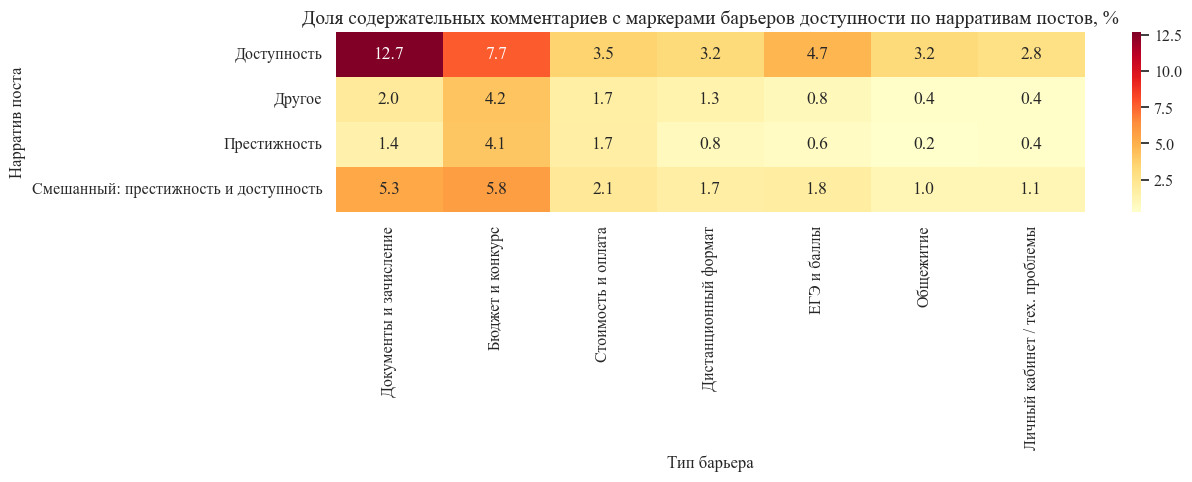

barrier_theme,Документы и зачисление,Бюджет и конкурс,Стоимость и оплата,Дистанционный формат,ЕГЭ и баллы,Общежитие,Личный кабинет / тех. проблемы
narrative_class,,,,,,,
Доступность,12.71,7.73,3.55,3.24,4.74,3.20,2.78
Другое,2.00,4.22,1.65,1.34,0.84,0.36,0.37
Престижность,1.41,4.09,1.73,0.80,0.57,0.23,0.37
Смешанный: престижность и доступность,5.32,5.77,2.09,1.72,1.77,1.01,1.06


In [64]:
barrier_matrix_pool = meaningful_comment_pool.copy()

barrier_matrix_patterns = {
    'admission_documents': r'поступ|прием|документ|зачисл|заявлен|договор|оригинал|анкета',
    'personal_account_tech': r'личн\w+ кабинет|госуслуг|ошибк|не\s+работа|не\s+активн|отклони|статус',
    'cost_payment': r'стоимост|оплат|платн|дорог|завышен|скидк|кредит',
    'budget_competition': r'бюджет|бюджетн\w+ мест|конкурс|мест|список|списки',
    'exam_scores': r'егэ|балл|вступительн|экзамен',
    'housing_campus': r'общежит|кампус|заселен|проживан',
    'distance_online': r'дистанцион|дистант|онлайн|удален'
}

for theme, pattern in barrier_matrix_patterns.items():
    barrier_matrix_pool[theme] = barrier_matrix_pool['comment_clean'].str.contains(
        pattern,
        regex=True,
        na=False
    )

barrier_long = []

for narrative, group in barrier_matrix_pool.groupby('narrative_class'):
    for theme in barrier_matrix_patterns:
        barrier_long.append({
            'narrative_class': narrative,
            'barrier_theme': theme,
            'n_comments': int(group[theme].sum()),
            'share_within_narrative': group[theme].mean(),
            'total_comments_in_narrative': len(group)
        })

barrier_matrix = pd.DataFrame(barrier_long)

barrier_matrix_pivot = barrier_matrix.pivot(
    index='narrative_class',
    columns='barrier_theme',
    values='share_within_narrative'
).fillna(0)

barrier_theme_labels = {
    'admission_documents': 'Документы и зачисление',
    'personal_account_tech': 'Личный кабинет / тех. проблемы',
    'cost_payment': 'Стоимость и оплата',
    'budget_competition': 'Бюджет и конкурс',
    'exam_scores': 'ЕГЭ и баллы',
    'housing_campus': 'Общежитие',
    'distance_online': 'Дистанционный формат'
}

barrier_matrix_pivot_ru = barrier_matrix_pivot.rename(columns=barrier_theme_labels)

plt.figure(figsize=(13, 5))
sns.heatmap(
    barrier_matrix_pivot_ru * 100,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd'
)
plt.title('Доля содержательных комментариев с маркерами барьеров доступности по нарративам постов, %')
plt.xlabel('Тип барьера')
plt.ylabel('Нарратив поста')
plt.tight_layout()
plt.show()

display((barrier_matrix_pivot_ru * 100).round(2))

In [65]:
post_to_comment_shift = (
    meaningful_comment_pool
    .groupby('narrative_class')
    .agg(
        n_comments=('comment_text', 'size'),
        access_barrier_share=('mentions_access_barrier', 'mean'),
        question_share=('is_question_comment', 'mean'),
        complaint_share=('complaint_marker', 'mean'),
        question_about_access_share=(
            'comment_response_type',
            lambda x: (x == 'question_about_access').mean()
        ),
        access_complaint_share=(
            'comment_response_type',
            lambda x: (x == 'access_barrier_complaint').mean()
        )
    )
    .reset_index()
)

display(post_to_comment_shift)

prestige_access_shift = (
    meaningful_comment_pool
    .loc[
        meaningful_comment_pool['narrative_class'].eq('Престижность') &
        meaningful_comment_pool['mentions_access_barrier'] &
        meaningful_comment_pool['focused_access_marker'] &
        meaningful_comment_pool['comment_token_count'].between(5, 80) &
        ~meaningful_comment_pool['has_external_link'] &
        ~meaningful_comment_pool['is_repeated_token_comment']
    ]
    .groupby(['post_id', 'source_nickname'])
    .agg(
        date=('date', 'first'),
        n_access_comments=('comment_text', 'size'),
        examples=('comment_short', lambda x: ' | '.join(x.head(3))),
        post_text=('post_text_short', 'first')
    )
    .reset_index()
    .sort_values('n_access_comments', ascending=False)
    .head(15)
)

display(prestige_access_shift)

,narrative_class,n_comments,access_barrier_share,question_share,complaint_share,question_about_access_share,access_complaint_share
0,Доступность,34362,0.20,0.49,0.05,0.15,0.01
1,Другое,65978,0.05,0.32,0.03,0.02,0.00
2,Престижность,65103,0.04,0.28,0.03,0.01,0.00
3,Смешанный: престижность и доступность,49963,0.10,0.35,0.04,0.05,0.00


,post_id,source_nickname,date,n_access_comments,examples,post_text
482,34383,rggu.csv,2021-08-03,17,"После 1го октября те, кто не привились, смогут посещать онлайн-пары? | Будет ли организованна дистанционка с 1 октября для тех, кто не привит, не ...",❗ Об организации учебного процесса в новом 2021-2022 году Новый учебный год в РГГУ начнется в гибридном (очном с применением электронного обучения...
117,9746,kutafina.csv,2022-06-13,12,"Будут ли дополнительные баллы за призерство в отборочном этапе олимпиады школьников Ранхигс? | Подскажите, будут ли добавляться дополнительно балл...","Абитуриент, привет! 👋🏻 Поговорим сегодня об индивидуальных достижениях? Собрали всю необходимую информацию в одном месте, не забудь сохранить 😉"
299,21751,miet.csv,2020-10-13,8,"Казалось бы, именно гуманитарные предметы предполагают очный формат семинаров. Итшников, которые на компах все делают, зачем на лабы гоняете перек...",✍🏻 ... И вот опять Студенты гуманитарных направлений полностью перешли на дистанционное обучение. Семинарские занятия и лабораторные работы у техн...
563,40369,mgpu.csv,2021-03-01,7,"Полтора года я учусь в МГПУ И полтора года я говорю, что наверное, все-таки, не зря я именно здесь, а не в другом университете. Поступала буквальн...","А помните, как мы придумывали первую ШСА, писали Тотальный диктант с Анатольевичем, шли от метро до Чечи на полуфинал КВН и строили универ в майнк..."
917,197824,mai.csv,2025-05-01,7,"Май это прекрасное время для подготовки к егэ🥲 | Май – это ""вот вам дополнительный балл за творческое задание"" (читай: за мем в презентации). | Ма...","Грозы, яркие зонты, первые пикники и поездки на дачу, начало сессии и совсем чуть-чуть до лета. С чем ещё у тебя ассоциируется май? ☂️ Продолжи в ..."
112,9368,sechenov.csv,2020-06-29,7,"Не надо никаких «праздников» онлайн! Просто выдайте уже бумажные дипломы! «Произнесение клятвы врача» онлайн, «наложат на себя <...> обязательства...",Дорогие друзья! 30 июня 2020 года состоится торжественная церемония выпуска специалистов Сеченовского Университета. Выпускников ждут поздравления ...
259,19552,shcukina.csv,2025-07-02,6,Отстаньте! Не ворчите! Пусть поступают! А вдруг среди них есть Смоктуновские или Хитяевы? Мечтать никому невредно. Особенно в их возрасте | Желаю ...,"Смотрите, какая трогательная и живая картина! Эти тревожные моменты ожидания на конкурсных прослушиваниях действительно наполнены особой энергией ..."
904,135658,rudn.csv,2024-08-31,6,Набрать высокие баллы и перевестись на бюджет❤️ | Отучиться и попасть на бюджетную основу в ординатуру в рудн и стать реаниматологом | Набрать выс...,"🤓 Первокурсники, какое желание вы хотите осуществить в первом учебном году? Пишите в комментариях! 🥳👕 Авторы трех самых оригинальных желаний выигр..."
62,5759,kutafina.csv,2020-08-06,6,Супер! Теперь осталось понять когда появится информация по распределению мест в общежитие. Заселение в общежитие случится до 2-го сентября? | Добр...,"Засиделись мы в онлайне — пора в студенческий офлайн😎 Это значит, что учеба начнется 1 сентября в привычном (наконец-то) режиме. Но есть свои огра..."
890,123505,rudn.csv,2022-10-31,6,"Курс по основам work-life balance для выпускников 📌Как грамотно распределять время, чтобы на последнем курсе учиться на «отлично», заниматься твор...","💭😜 Первокурсники, вы здесь? Вы нужны нам, ведь мы объявляем конкурс: «Мечтать не запрещается!» 🤓Предлагаем вам придумать предмет (дисциплину), кот..."


Создание файлов для ручной валидации

In [53]:
validation_base = comms.copy()
validation_base['text_for_annotation'] = (validation_base['text'].astype('str')
                                         .str.replace(r'\s+', ' ', regex=True)
                                         .str.strip().str[:1000])

comments_part = validation_base['comments'].astype(str).str.split(r'\s+\|\s+', regex=True)
validation_base['comments_for_annotation'] = comments_part.apply(
    lambda items: '\n---\n'.join([str(x).strip() for x in items if str(x).strip()][:8])[:1600])
validation_base['meaningful_comments_clean'] = comments_part.apply(
    lambda items: '\n---\n'.join([str(x).strip() for x in items if len(str(x).split())>=5][:8])[:1600])

validation_base['comments_validation'] = np.select([validation_base['contest_like_flag'].eq(1),
                                                   validation_base['comment_question_part'].ge(0.3),
                                                   validation_base['comment_meaningful_part'].ge(0.65),
                                                   validation_base['comment_short_part'].ge(0.6)], 
                                                  ['contest_or_mechanical', 'question_heavy', 'meaningful_heavy', 'short_or_ritualistic'], default='ordinary')

post_base_cols = ['post_id', 'date', 'year', 'month', 'likes', 'comments_count', 'reposts',
       'views', 'source_nickname', 'narrative_class', 'prestige_marker_count', 'access_marker_count',
                 'prestige_density', 'access_density', 'sentiment_label', 'sentiment_score',
                 'likes_p1000_views', 'comments_p1000_views', 'reposts_p1000_views', 'text_for_annotation']

comms_base_cols = ['post_id', 'date', 'year', 'month',  'source_nickname',
                  'comments_validation', 'narrative_class', 'comments_count', 'contest_like_flag',
                  'comment_question_part', 'comment_meaningful_part', 'comment_short_part', 'comment_duplicate_part',
                  'comment_ritualistic_part', 'meaningful_comm_clean', 'comment_access_barrier_mentions',
                  'text_for_annotation', 'comments_for_annotation', 'meaningful_comments_clean']

post_base_cols = [col for col in post_base_cols if col in validation_base.columns]
comms_base_cols = [col for col in comms_base_cols if col in validation_base.columns]

posts_val = validation_base[post_base_cols]
comms_val = validation_base[comms_base_cols]

posts_val.to_csv('posts_for_validation.csv')
comms_val.to_csv('comments_for_validation.csv')

## Advanced-модели и метрики качества

Этот блок дополняет baseline-модели более сильными решениями. Его задача – проверить, насколько разные группы признаков связаны с высоким содержательным откликом в комментариях.  

  Целевая переменная в данном случае – это высокий содержательный отклик в комментариях. Пост относится к положительному классу, если `meaningful_comm_clean` выше 75% перцентиля. 

   Важно развести три аналитические постановки. Вариант `post + comment_layer` использует признаки публикации и уже наблюдаемого слоя комментариев, поэтому рассматривается как диагностическая/объяснительная модель, а не как прогноз до публикации. Вариант `post_only` исключает признаки комментариев, но сохраняет постпубликационные метаданные вроде просмотров. Для наиболее строгой прогнозной постановки дополнительно строится вариант `pre_publication`, в котором исключаются и комментарийные признаки, и метрики, возникающие после публикации.


In [13]:
# функция для семплирования выборки
def sampled(data, n):
    parts=[]
    for _, group in data.groupby('narrative_class', dropna=False):
        target = max(250, int(n*len(group)/len(data)))
        parts.append(group.sample(min(target, len(group)), random_state=42))
    out = pd.concat(parts)
    return out.sample(min(n, len(out)), random_state=42).reset_index(drop=True)

def top_source(series, top=25):
    top_sources = series.value_counts().head(top).index
    return series.where(series.isin(top_sources), 'other_source')
    
ml = comms.loc[comms['meaningful_comm_clean'].notna() &comms['contest_like_flag'].fillna(0).eq(0) 
                                & comms['views'].gt(0) & comms['text_clean'].str.len().gt(40)].copy()

# ml = sampled(ml, n=50002)
ml['source_grouped'] = top_source(ml['source_nickname'])

threshold = float(ml['meaningful_comm_clean'].quantile(0.75))
if  threshold< 1:
    threshold = 1.0

ml['high_content_comment_response'] = (ml['meaningful_comm_clean']> threshold).astype(int)

print('Объем выборки:', len(ml))
print('Порог таргета:', threshold)
print('Доля положительного класса в выборке:', round(ml['high_content_comment_response'].mean(), 3))
display(ml['narrative_class'].value_counts(normalize=True).rename('part').reset_index())

Объем выборки: 92012
Порог таргета: 3.6
Доля положительного класса в выборке: 0.25


,narrative_class,part
0,Престижность,0.34
1,Другое,0.28
2,Смешанный: престижность и доступность,0.25
3,Доступность,0.13


In [14]:
# численные признаки
num_features = ['year', 'month', 'text_len', 'token_count', 'emodji_count', 'exclamation_count',
                    'question_count', 'has_url', 'caps_part', 'prestige_density', 'access_density',
                    'financial_access_density', 'procedural_access_density', 'informational_access_density',
                    'infrastructure_support_density', 'sentiment_score', 'log_views',
               'comment_question_part', 'comment_meaningful_part', 'comment_short_part',
               'comment_duplicate_part', 'comment_sentiment_score', 'comment_access_barrier_mentions']

# категориальные признаки
cat_features = ['source_grouped', 'narrative_class', 'sentiment_label', 'season']

# выделение таргета, разделение на тест и трейн, сотавление пайплайнов для cat и num признаков
X = ml[['text_clean'] + num_features + cat_features]
y = ml['high_content_comment_response']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler(with_mean=False))])

cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                    ('ohe', OneHotEncoder(handle_unknown='ignore'))])
# создание статистики
text_tfidf = TfidfVectorizer(max_features=7000, 
                            min_df=3,
                            max_df=0.85, 
                            ngram_range=(1,2),
                            stop_words=sorted(ru_stopwords),
                            token_pattern=r'(?u)\b[а-яa-z]{3,}\b',
                            sublinear_tf=True)

text_plus_features = ColumnTransformer(transformers=[('text', text_tfidf, 'text_clean'),
                                                    ('num', num_pipe, num_features),
                                                    ('cat', cat_pipe, cat_features)], sparse_threshold=0.3)

only_features = ColumnTransformer(transformers=[('num', num_pipe, num_features),
                                                ('cat', cat_pipe, cat_features)], sparse_threshold=0.2)


In [15]:
def model_metrics(name, model, model_family, X_train, X_test, y_train, y_test, fit=True):
    if fit:
        model.fit(X_train, y_train)
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    if hasattr(model, 'predict_proba'):
        score_train = model.predict_proba(X_train)[:,1]
        score_test = model.predict_proba(X_test)[:,1]

    elif hasattr(model, 'decision_function'):
        score_train = model.decision_function(X_train)
        score_test = model.decision_function(X_test)
    else:
        score_train = None
    row = {'model': name,
           'model_family': model_family,
          'train_accuracy': accuracy_score(y_train, pred_train),
          'test_accuracy': accuracy_score(y_test, pred_test), 
           'train_balanced_accuracy': balanced_accuracy_score(y_train, pred_train),
          'test_balanced_accuracy': balanced_accuracy_score(y_test, pred_test),
           'train_F1': f1_score(y_train, pred_train, zero_division=0),
           'test_F1': f1_score(y_test, pred_test, zero_division=0),
           'test_precision': precision_score(y_test, pred_test, zero_division=0),
           'test_recall': recall_score(y_test, pred_test, zero_division=0),
           'train_roc_auc': roc_auc_score(y_train, score_train) if score_train is not None else np.nan,
           'test_roc_auc': roc_auc_score(y_test, score_test) if score_train is not None else np.nan,
           'test_pr_auc': average_precision_score(y_test, score_test) if score_train is not None else np.nan}
    row['overfit_F1_gap'] = row['train_F1'] - row['test_F1']

    return row

In [16]:
# перечисляем модели для сравнения и их параметры
models = {'Dummy most frequent': (Pipeline([('prep', only_features),
                                          ('model', DummyClassifier(strategy='most_frequent'))]), 'baseline_dummy'),
         'Logistic regression + TF-IDF': (Pipeline([('prep', text_plus_features),
                                                   ('model', LogisticRegression(max_iter=1200,
                                                                               class_weight='balanced',
                                                                               solver='liblinear',
                                                                               random_state=42))]), 'classical_baseline'),
          'Engineered + RandomForest': (Pipeline([('prep', only_features),
                                          ('model', RandomForestClassifier(n_estimators=120,
                                                                           max_depth=14,
                                                                           min_samples_leaf=20,
                                                                           class_weight='balanced_subsample',
                                                                           n_jobs=1,
                                                                           random_state=42))]),  'nonlinear_bagging'),      
          'Engineered + HistGradientBoosting': (Pipeline([('prep', only_features),
                           ('model', HistGradientBoostingClassifier(max_iter=180,
                                                                    learning_rate=0.06,
                                                                    max_leaf_nodes=31,
                                                                    l2_regularization=0.1,
                                                                    random_state=42))]), 'boosting_sklearn')}    


rows = []
fit_models = {}

progress_bar = tqdm(models.items(), total=len(models), desc='Обучение advanced-моделей')
for name, (model, model_family) in progress_bar:
    progress_bar.set_postfix_str(name)

    rows.append(model_metrics(name, model, model_family, X_train, X_test, y_train, y_test))
    fit_models[name] = model

Обучение advanced-моделей: 100%|█| 4/4 [00:30<00:00,  7.71s/it, Engineered + His


In [17]:
X_cat = ml[num_features+cat_features]
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X_cat, y, test_size=0.25, random_state=42, stratify=y)

cat = CatBoostClassifier(iterations=260,
                        learning_rate=0.06,
                        depth=6,
                        loss_function='Logloss',
                        eval_metric='F1',
                        class_weights=[1.0, (1-y.mean())/max(y.mean(), 1e-6)],
                        random_seed=42,
                        verbose=False)
cat.fit(X_train_cat, y_train_cat, cat_features=cat_features)
rows.append(model_metrics('Engineered + CatBoost', cat, 'boosting_catboost', X_train_cat, X_test_cat, y_train_cat, y_test_cat, fit=False))

In [18]:
X_cat = ml[num_features+cat_features]
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X_cat, y, test_size=0.25, random_state=42, stratify=y)

xgb = Pipeline([('prep', only_features),
                ('model', XGBClassifier(n_estimators=250,
                                       max_depth=4,
                                       learning_rate=0.06,
                                       subsample=0.85,
                                       colsample_bytree=0.8,
                                       reg_lambda=2.0,
                                       eval_metric='logloss',
                                       n_jobs=1,
                                       random_state=42,
                                       scale_pos_weight=(1-y.mean())/max(y.mean(), 1e-6)))])
rows.append(model_metrics('Engineered + XGBoost', xgb, 'boosting_xgboost', X_train, X_test, y_train, y_test))
fit_models['Engineered + XGBoost'] = xgb

## Статичные эмбеддинги Word2Vec/FastText как baseline

In [19]:
# определяем функции для усреднения токенов, объединенных с числовыми признаками
def avg_vectors(model, tokenised, vector_size):
    rows=[]
    for tokens in tokenised:
        vectors = [model.wv[token] for token in tokens if token in model.wv]
        rows.append(np.mean(vectors, axis=0) if vectors else np.zeros(vector_size))
    return np.vstack(rows)

def doc_avg_vectors(texts, vector_size=160):
    tokenised = texts.fillna('').map(tokenise_clean).tolist()
    params = dict(sentences=tokenised, vector_size=vector_size, window=2, min_count=3, sg=0, workers=1, seed=42, epochs=8)
    w2v = Word2Vec(**params)
    ft = FastText(**params)
    return np.hstack([avg_vectors(w2v, tokenised, vector_size), avg_vectors(ft, tokenised, vector_size)])

X_doc = doc_avg_vectors(ml['text_clean'])
X_doc = np.hstack([X_doc, StandardScaler().fit_transform(ml[num_features].fillna(0).to_numpy())])
X_doc = np.nan_to_num(X_doc, nan=0.0, posinf=0.0, neginf=0.0)
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_doc, y, test_size=0.25, random_state=42, stratify=y)

w2v_logit = LogisticRegression(max_iter=1200, class_weight='balanced', solver='liblinear', random_state=42)
rows.append(model_metrics('Word2Vec + FastText doc avg + LogisticRegression', w2v_logit, 'static_embeddings', X_train_d, X_test_d, y_train_d, y_test_d))

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [20]:
metrics = pd.DataFrame(rows).sort_values(['test_F1', 'test_roc_auc', 'test_pr_auc'], ascending=False)
metrics.insert(1, 'target', 'high_content_comment_response_q75')
metrics.insert(2, 'sample_size', len(ml))
metrics.insert(3, 'target_threshold', threshold)
metrics.insert(4, 'positive_rate', y.mean())


display(Markdown(f'''Advanced-модели обучались на одном с baseline-моделями таргете.  
Порог таргет: {threshold}.  
Доля положительного класса: {y.mean():.2f}.  
Лучшая модель на данный момент – {metrics.iloc[0]["model"]}, test_F1 = {metrics.iloc[0]["test_F1"]:.2f},
ROC-AUC = {metrics.iloc[0]["test_roc_auc"]:.2f}'''))

display(metrics)

Advanced-модели обучались на одном с baseline-моделями таргете.  
Порог таргет: 3.6.  
Доля положительного класса: 0.25.  
Лучшая модель на данный момент – Engineered + HistGradientBoosting, test_F1 = 0.75,
ROC-AUC = 0.93

,model,target,sample_size,target_threshold,positive_rate,model_family,train_accuracy,test_accuracy,train_balanced_accuracy,test_balanced_accuracy,train_F1,test_F1,test_precision,test_recall,train_roc_auc,test_roc_auc,test_pr_auc,overfit_F1_gap
3,Engineered + HistGradientBoosting,high_content_comment_response_q75,92012,3.60,0.25,boosting_sklearn,0.90,0.89,0.83,0.82,0.77,0.75,0.87,0.67,0.94,0.93,0.87,0.02
4,Engineered + CatBoost,high_content_comment_response_q75,92012,3.60,0.25,boosting_catboost,0.86,0.86,0.85,0.85,0.75,0.74,0.68,0.82,0.93,0.93,0.86,0.01
5,Engineered + XGBoost,high_content_comment_response_q75,92012,3.60,0.25,boosting_xgboost,0.86,0.86,0.85,0.85,0.75,0.74,0.67,0.83,0.94,0.93,0.86,0.01
2,Engineered + RandomForest,high_content_comment_response_q75,92012,3.60,0.25,nonlinear_bagging,0.85,0.84,0.85,0.83,0.74,0.72,0.64,0.82,0.93,0.92,0.82,0.02
1,Logistic regression + TF-IDF,high_content_comment_response_q75,92012,3.60,0.25,classical_baseline,0.78,0.74,0.79,0.74,0.65,0.59,0.49,0.73,0.87,0.82,0.63,0.06
6,Word2Vec + FastText doc avg + LogisticRegression,high_content_comment_response_q75,92012,3.60,0.25,static_embeddings,0.71,0.71,0.72,0.71,0.56,0.55,0.45,0.72,0.80,0.80,0.57,0.00
0,Dummy most frequent,high_content_comment_response_q75,92012,3.60,0.25,baseline_dummy,0.75,0.75,0.50,0.50,0.00,0.00,0.00,0.00,0.50,0.50,0.25,0.00


In [21]:
best_name = metrics.iloc[0]["model"]
best_model = fit_models[best_name]

best_pred = best_model.predict(X_test)
report = classification_report(y_test, best_pred, zero_division=0)
confusion_m = pd.DataFrame(confusion_matrix(y_test, best_pred),
                               index=['real_0', 'real_1'],
                               columns=['pred_0', 'pred_1'])

display(Markdown(f'''Лучшей моделью по метрике F1 стала **{best_name}**.  
Confusion_matrix & classification_report для оценки эффективности классификации: '''))

display(confusion_m)
print(report)

Лучшей моделью по метрике F1 стала **Engineered + HistGradientBoosting**.  
Confusion_matrix & classification_report для оценки эффективности классификации: 

,pred_0,pred_1
real_0,16662,594
real_1,1923,3824


              precision    recall  f1-score   support

           0       0.90      0.97      0.93     17256
           1       0.87      0.67      0.75      5747

    accuracy                           0.89     23003
   macro avg       0.88      0.82      0.84     23003
weighted avg       0.89      0.89      0.89     23003



## Сравнение  модели со слоем комментариев (post + comment_layer) и без (post_only)

In [22]:
comment_num_features = [col for col in num_features if col.startswith('comment')]

post_only_num_features = [col for col in num_features if col not in comment_num_features]


X_post = ml[['text_clean'] + post_only_num_features+cat_features]
X_train_post, X_test_post, y_train_post, y_test_post = train_test_split(X_post, y, test_size=0.25, random_state=42, stratify=y)



num_pipe_post = Pipeline([('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler(with_mean=False))])

cat_pipe_post = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                    ('ohe', OneHotEncoder(handle_unknown='ignore'))])
text_tfidf_post = TfidfVectorizer(max_features=7000, 
                            min_df=3,
                            max_df=0.85, 
                            ngram_range=(1,2),
                            stop_words=sorted(ru_stopwords),
                            token_pattern=r'(?u)\b[а-яa-z]{3,}\b',
                            sublinear_tf=True)

post_text_plus_features = ColumnTransformer(transformers=[('text', text_tfidf_post, 'text_clean'),
                                                    ('num', num_pipe_post, post_only_num_features),
                                                    ('cat', cat_pipe_post, cat_features)], sparse_threshold=0.3)

post_only_features = ColumnTransformer(transformers=[('num', num_pipe_post, post_only_num_features),
                                                ('cat', cat_pipe_post, cat_features)], sparse_threshold=0.2)



post_only_models ={
         'Post_only Logistic regression + TF-IDF': (Pipeline([('prep', post_text_plus_features),
                                                   ('model', LogisticRegression(max_iter=1200,
                                                                               class_weight='balanced',
                                                                               solver='liblinear',
                                                                               random_state=42))]), 'post_only_classical_baseline'),
                    'Post_only HistGradientBoosting': (Pipeline([('prep', post_only_features),
                           ('model', HistGradientBoostingClassifier(max_iter=180,
                                                                    learning_rate=0.06,
                                                                    max_leaf_nodes=31,
                                                                    l2_regularization=0.1,
                                                                    random_state=42))]), 'post_only_boosting_sklearn')}    



post_only__rows = []

progress_bar_post_only = tqdm(post_only_models.items(), total=len(post_only_models), desc='Обучение post_only advanced-моделей')
for name, (model, model_family) in progress_bar_post_only:
    progress_bar_post_only.set_postfix_str(name)

    post_only__rows.append(model_metrics(name, model, model_family, X_train_post, X_test_post, y_train_post, y_test_post))


metrics_post_only = pd.DataFrame(post_only__rows).sort_values(['test_F1', 'test_roc_auc', 'test_pr_auc'], ascending=False)
metrics_post_only.insert(1, 'target', 'high_content_comment_response_q75')
metrics_post_only.insert(2, 'sample_size', len(ml))
metrics_post_only.insert(3, 'target_threshold', threshold)
metrics_post_only.insert(4, 'positive_rate', y.mean())

comparison_layers = pd.concat([metrics.assign(feature_layer='post + comment_layer'),
                              metrics_post_only.assign(feature_layer='post_only')],
                             axis=0, 
                             ignore_index=True).sort_values(['test_F1', 'test_roc_auc', 'test_pr_auc'], ascending=False)

display(Markdown(f'''Данная таблица демонстрирует различия между двумя постановками:
`post + comment_layer` и `post_only`.   
Если `post_only` показывает более слабые результаты, это значит, что часть качества в метриках
приходит из наблюдаемого слоя комментариев. Поэтому `post + comment_layer` интерпретируется как
диагностическая модель уже наблюдаемой реакции, а не как прогноз до публикации.'''))

display(comparison_layers[['feature_layer', 'model',
       'model_family', 'train_F1',
       'test_F1', 'test_precision', 'test_recall', 'train_roc_auc',
       'test_roc_auc', 'test_pr_auc', 'overfit_F1_gap']])


Обучение post_only advanced-моделей: 100%|█| 2/2 [00:23<00:00, 11.91s/it, Post_o


Данная таблица демонстрирует различия между двумя постановками:
`post + comment_layer` и `post_only`.   
Если `post_only` показывает более слабые результаты, это значит, что часть качества в метриках
приходит из наблюдаемого слоя комментариев. Поэтому `post + comment_layer` интерпретируется как
диагностическая модель уже наблюдаемой реакции, а не как прогноз до публикации.

,feature_layer,model,model_family,train_F1,test_F1,test_precision,test_recall,train_roc_auc,test_roc_auc,test_pr_auc,overfit_F1_gap
0,post + comment_layer,Engineered + HistGradientBoosting,boosting_sklearn,0.77,0.75,0.87,0.67,0.94,0.93,0.87,0.02
1,post + comment_layer,Engineered + CatBoost,boosting_catboost,0.75,0.74,0.68,0.82,0.93,0.93,0.86,0.01
2,post + comment_layer,Engineered + XGBoost,boosting_xgboost,0.75,0.74,0.67,0.83,0.94,0.93,0.86,0.01
3,post + comment_layer,Engineered + RandomForest,nonlinear_bagging,0.74,0.72,0.64,0.82,0.93,0.92,0.82,0.02
4,post + comment_layer,Logistic regression + TF-IDF,classical_baseline,0.65,0.59,0.49,0.73,0.87,0.82,0.63,0.06
5,post + comment_layer,Word2Vec + FastText doc avg + LogisticRegression,static_embeddings,0.56,0.55,0.45,0.72,0.80,0.80,0.57,0.00
7,post_only,Post_only Logistic regression + TF-IDF,post_only_classical_baseline,0.60,0.53,0.45,0.65,0.83,0.76,0.55,0.07
8,post_only,Post_only HistGradientBoosting,post_only_boosting_sklearn,0.48,0.44,0.72,0.31,0.82,0.78,0.60,0.04
6,post + comment_layer,Dummy most frequent,baseline_dummy,0.00,0.00,0.00,0.00,0.50,0.50,0.25,0.00


Модель `post + comment_layer` рассматривается в качестве диагностической и объяснительной: она показывает, какие признаки уже наблюдаемого обсуждения связаны с высоким содержательным откликом. Ее нельзя трактовать как прогноз до публикации, потому что она включает признаки комментарийного слоя, частично связанные с целевой переменной `meaningful_comm_clean`.

Вариант `post_only` исключает комментарийный слой, но в нем остается `log_views`, то есть постпубликационная метрика. Поэтому ниже отдельно строится более строгая постановка `pre_publication`: только текст публикации, источник, календарные признаки, нарративная рамка и тональность, без просмотров и без комментариев.


### Проверка без постпубликационных признаков (`pre_publication`)

Чтобы отделить объяснительную модель от более строгой прогнозной постановки, дополнительно строится вариант `pre_publication`. Из признаков исключаются комментарийный слой и метрики, возникающие после публикации поста. В этой постановке остаются только признаки, которые можно знать до или в момент публикации: текст, источник, календарные характеристики, нарративная классификация и тональность текста.

Эта модель не должна обязательно быть самой сильной по метрикам. Ее задача – показать, сохраняется ли самостоятельный сигнал признаков без leakage из комментариев и просмотров.


In [23]:
post_publication_num_features = ['log_views']
pre_publication_num_features = [
    col for col in post_only_num_features
    if col not in post_publication_num_features
]

X_pre = ml[['text_clean'] + pre_publication_num_features + cat_features]
X_train_pre, X_test_pre, y_train_pre, y_test_pre = train_test_split(
    X_pre, y, test_size=0.25, random_state=42, stratify=y
)

num_pipe_pre = Pipeline([('imputer', SimpleImputer(strategy='median')),
                         ('scaler', StandardScaler(with_mean=False))])

cat_pipe_pre = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                         ('ohe', OneHotEncoder(handle_unknown='ignore'))])

text_tfidf_pre = TfidfVectorizer(max_features=7000,
                                 min_df=3,
                                 max_df=0.85,
                                 ngram_range=(1, 2),
                                 stop_words=sorted(ru_stopwords),
                                 token_pattern=r'(?u)\b[а-яa-z]{3,}\b',
                                 sublinear_tf=True)

pre_text_plus_features = ColumnTransformer(
    transformers=[('text', text_tfidf_pre, 'text_clean'),
                  ('num', num_pipe_pre, pre_publication_num_features),
                  ('cat', cat_pipe_pre, cat_features)],
    sparse_threshold=0.3)

pre_only_features = ColumnTransformer(
    transformers=[('num', num_pipe_pre, pre_publication_num_features),
                  ('cat', cat_pipe_pre, cat_features)],
    sparse_threshold=0.2)

pre_publication_models = {
    'Pre_publication Logistic regression + TF-IDF': (
        Pipeline([('prep', pre_text_plus_features),
                  ('model', LogisticRegression(max_iter=1200,
                                               class_weight='balanced',
                                               solver='liblinear',
                                               random_state=42))]),
        'pre_publication_classical_baseline'),
    'Pre_publication HistGradientBoosting': (
        Pipeline([('prep', pre_only_features),
                  ('model', HistGradientBoostingClassifier(max_iter=180,
                                                           learning_rate=0.06,
                                                           max_leaf_nodes=31,
                                                           l2_regularization=0.1,
                                                           random_state=42))]),
        'pre_publication_boosting_sklearn')
}

pre_publication_rows = []

progress_bar_pre = tqdm(pre_publication_models.items(),
                        total=len(pre_publication_models),
                        desc='Обучение pre_publication моделей')
for name, (model, model_family) in progress_bar_pre:
    progress_bar_pre.set_postfix_str(name)
    pre_publication_rows.append(
        model_metrics(name, model, model_family,
                      X_train_pre, X_test_pre, y_train_pre, y_test_pre)
    )

metrics_pre_publication = pd.DataFrame(pre_publication_rows).sort_values(
    ['test_F1', 'test_roc_auc', 'test_pr_auc'], ascending=False)
metrics_pre_publication.insert(1, 'target', 'high_content_comment_response_q75')
metrics_pre_publication.insert(2, 'sample_size', len(ml))
metrics_pre_publication.insert(3, 'target_threshold', threshold)
metrics_pre_publication.insert(4, 'positive_rate', y.mean())

comparison_layers_extended = pd.concat([
    metrics.assign(feature_layer='post + comment_layer'),
    metrics_post_only.assign(feature_layer='post_only'),
    metrics_pre_publication.assign(feature_layer='pre_publication')
], axis=0, ignore_index=True).sort_values(
    ['test_F1', 'test_roc_auc', 'test_pr_auc'], ascending=False)

layer_best = (comparison_layers_extended
              .sort_values(['feature_layer', 'test_F1', 'test_pr_auc', 'test_roc_auc'],
                           ascending=[True, False, False, False])
              .groupby('feature_layer', as_index=False)
              .head(1)
              .sort_values('test_F1', ascending=False))

display(Markdown(f'''Сравнение трех постановок показывает, какая часть качества связана с разными слоями данных.

- `post + comment_layer` – диагностическая модель уже наблюдаемого обсуждения; в ней есть leakage для прогнозной задачи.
- `post_only` – модель без комментарийного слоя, но с постпубликационными метаданными, включая просмотры.
- `pre_publication` – наиболее строгая прогнозная постановка без комментариев и просмотров.

Если качество `pre_publication` ниже, это не ошибка модели, а ожидаемый результат: из нее исключены признаки, которые становятся известны только после публикации и напрямую описывают уже возникший отклик.'''))

display(comparison_layers_extended[['feature_layer', 'model', 'model_family',
                                    'train_F1', 'test_F1', 'test_precision',
                                    'test_recall', 'test_roc_auc', 'test_pr_auc',
                                    'overfit_F1_gap']])

display(Markdown('''Лучшие модели по каждому уровню признаков:'''))
display(layer_best[['feature_layer', 'model', 'test_F1', 'test_precision',
                    'test_recall', 'test_roc_auc', 'test_pr_auc']])


Обучение pre_publication моделей: 100%|█| 2/2 [01:57<00:00, 58.80s/it, Pre_publi


Сравнение трех постановок показывает, какая часть качества связана с разными слоями данных.

- `post + comment_layer` – диагностическая модель уже наблюдаемого обсуждения; в ней есть leakage для прогнозной задачи.
- `post_only` – модель без комментарийного слоя, но с постпубликационными метаданными, включая просмотры.
- `pre_publication` – наиболее строгая прогнозная постановка без комментариев и просмотров.

Если качество `pre_publication` ниже, это не ошибка модели, а ожидаемый результат: из нее исключены признаки, которые становятся известны только после публикации и напрямую описывают уже возникший отклик.

,feature_layer,model,model_family,train_F1,test_F1,test_precision,test_recall,test_roc_auc,test_pr_auc,overfit_F1_gap
0,post + comment_layer,Engineered + HistGradientBoosting,boosting_sklearn,0.77,0.75,0.87,0.67,0.93,0.87,0.02
1,post + comment_layer,Engineered + CatBoost,boosting_catboost,0.75,0.74,0.68,0.82,0.93,0.86,0.01
2,post + comment_layer,Engineered + XGBoost,boosting_xgboost,0.75,0.74,0.67,0.83,0.93,0.86,0.01
3,post + comment_layer,Engineered + RandomForest,nonlinear_bagging,0.74,0.72,0.64,0.82,0.92,0.82,0.02
4,post + comment_layer,Logistic regression + TF-IDF,classical_baseline,0.65,0.59,0.49,0.73,0.82,0.63,0.06
5,post + comment_layer,Word2Vec + FastText doc avg + LogisticRegression,static_embeddings,0.56,0.55,0.45,0.72,0.80,0.57,0.00
7,post_only,Post_only Logistic regression + TF-IDF,post_only_classical_baseline,0.60,0.53,0.45,0.65,0.76,0.55,0.07
9,pre_publication,Pre_publication Logistic regression + TF-IDF,pre_publication_classical_baseline,0.58,0.50,0.42,0.61,0.72,0.51,0.08
8,post_only,Post_only HistGradientBoosting,post_only_boosting_sklearn,0.48,0.44,0.72,0.31,0.78,0.60,0.04
10,pre_publication,Pre_publication HistGradientBoosting,pre_publication_boosting_sklearn,0.41,0.38,0.75,0.26,0.74,0.56,0.03


Лучшие модели по каждому уровню признаков:

,feature_layer,model,test_F1,test_precision,test_recall,test_roc_auc,test_pr_auc
0,post + comment_layer,Engineered + HistGradientBoosting,0.75,0.87,0.67,0.93,0.87
7,post_only,Post_only Logistic regression + TF-IDF,0.53,0.45,0.65,0.76,0.55
9,pre_publication,Pre_publication Logistic regression + TF-IDF,0.50,0.42,0.61,0.72,0.51


Интерпретация сравнения должна строиться не как соревнование “какая модель лучше вообще”, а как сравнение трех разных исследовательских вопросов. `post + comment_layer` показывает, насколько характеристики уже наблюдаемого обсуждения согласованы с высоким содержательным откликом. `post_only` показывает, что часть сигнала сохраняется без прямых признаков комментариев, но при наличии просмотров. `pre_publication` является наиболее строгой прогнозной проверкой: если она уступает двум предыдущим постановкам, это означает, что значительная часть объясняющей информации появляется уже после публикации и в процессе реакции аудитории.


In [24]:
from sklearn.base import clone
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, balanced_accuracy_score
)

def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return model.predict(X)

def eval_holdout(name, model, X_train, X_test, y_train, y_test, scheme):
    fitted = clone(model)
    fitted.fit(X_train, y_train)

    pred = fitted.predict(X_test)
    score = get_scores(fitted, X_test)

    return {
        "scheme": scheme,
        "model": name,
        "n_train": len(y_train),
        "n_test": len(y_test),
        "test_F1": f1_score(y_test, pred, zero_division=0),
        "test_precision": precision_score(y_test, pred, zero_division=0),
        "test_recall": recall_score(y_test, pred, zero_division=0),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "test_roc_auc": roc_auc_score(y_test, score),
        "test_pr_auc": average_precision_score(y_test, score),
    }

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def make_logreg_tfidf(num_cols, cat_cols):
    num_pipe_local = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False))
    ])

    cat_pipe_local = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", make_ohe())
    ])

    prep = ColumnTransformer(
        transformers=[
            ("text", TfidfVectorizer(
                max_features=7000,
                min_df=3,
                max_df=0.85,
                ngram_range=(1, 2),
                stop_words=sorted(ru_stopwords),
                token_pattern=r"(?u)\b[а-яa-z]{3,}\b",
                sublinear_tf=True
            ), "text_clean"),
            ("num", num_pipe_local, num_cols),
            ("cat", cat_pipe_local, cat_cols),
        ],
        sparse_threshold=0.3
    )

    return Pipeline([
        ("prep", prep),
        ("model", LogisticRegression(
            max_iter=1200,
            class_weight="balanced",
            random_state=42
        ))
    ])

In [25]:
comment_num_features = [col for col in num_features if col.startswith("comment")]
post_only_num_features = [col for col in num_features if col not in comment_num_features]
pre_publication_num_features = [
    col for col in post_only_num_features
    if col != "log_views"
]

robust_specs = {
    "post + comment_layer": (num_features, cat_features),
    "post_only": (post_only_num_features, cat_features),
    "pre_publication": (pre_publication_num_features, cat_features),
}

In [26]:
year_rows = []

train_mask = ml["year"].between(2020, 2024)
test_mask = ml["year"].eq(2025)

for layer, (num_cols, cat_cols) in robust_specs.items():
    feature_cols = ["text_clean"] + num_cols + cat_cols

    X_train_year = ml.loc[train_mask, feature_cols]
    X_test_year = ml.loc[test_mask, feature_cols]
    y_train_year = ml.loc[train_mask, "high_content_comment_response"]
    y_test_year = ml.loc[test_mask, "high_content_comment_response"]

    model = make_logreg_tfidf(num_cols, cat_cols)

    year_rows.append(
        eval_holdout(
            name=f"{layer} LogisticRegression + TF-IDF",
            model=model,
            X_train=X_train_year,
            X_test=X_test_year,
            y_train=y_train_year,
            y_test=y_test_year,
            scheme="train_2020_2024_test_2025"
        )
    )

year_split_results = pd.DataFrame(year_rows).sort_values("test_F1", ascending=False)
display(year_split_results)

,scheme,model,n_train,n_test,test_F1,test_precision,test_recall,test_balanced_accuracy,test_roc_auc,test_pr_auc
0,train_2020_2024_test_2025,post + comment_layer LogisticRegression + TF-IDF,72008,20004,0.62,0.52,0.77,0.76,0.85,0.68
1,train_2020_2024_test_2025,post_only LogisticRegression + TF-IDF,72008,20004,0.58,0.51,0.69,0.72,0.80,0.62
2,train_2020_2024_test_2025,pre_publication LogisticRegression + TF-IDF,72008,20004,0.52,0.44,0.63,0.67,0.74,0.54


In [27]:
group_col = "source_nickname" if "source_nickname" in ml.columns else "source_grouped"

gkf_rows = []
scoring = {
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

for layer, (num_cols, cat_cols) in robust_specs.items():
    feature_cols = ["text_clean"] + num_cols + cat_cols
    X_group = ml[feature_cols]
    y_group = ml["high_content_comment_response"]
    groups = ml[group_col]

    model = make_logreg_tfidf(num_cols, cat_cols)

    cv_res = cross_validate(
        model,
        X_group,
        y_group,
        groups=groups,
        cv=GroupKFold(n_splits=5),
        scoring=scoring,
        n_jobs=1
    )

    gkf_rows.append({
        "scheme": f"GroupKFold by {group_col}",
        "feature_layer": layer,
        "F1_mean": cv_res["test_f1"].mean(),
        "F1_std": cv_res["test_f1"].std(),
        "PR_AUC_mean": cv_res["test_pr_auc"].mean(),
        "ROC_AUC_mean": cv_res["test_roc_auc"].mean(),
        "balanced_accuracy_mean": cv_res["test_balanced_accuracy"].mean(),
    })

groupkfold_results = pd.DataFrame(gkf_rows).sort_values("F1_mean", ascending=False)
display(groupkfold_results)

,scheme,feature_layer,F1_mean,F1_std,PR_AUC_mean,ROC_AUC_mean,balanced_accuracy_mean
0,GroupKFold by source_nickname,post + comment_layer,0.52,0.03,0.54,0.77,0.69
1,GroupKFold by source_nickname,post_only,0.47,0.04,0.45,0.70,0.65
2,GroupKFold by source_nickname,pre_publication,0.38,0.01,0.36,0.62,0.58


In [28]:
ablation_specs = {
    "full_post_comment_layer": (num_features, cat_features),
    "without_comment_meaningful_part": (
        [c for c in num_features if c != "comment_meaningful_part"],
        cat_features
    ),
    "without_log_views": (
        [c for c in num_features if c != "log_views"],
        cat_features
    ),
    "without_narrative_class": (
        num_features,
        [c for c in cat_features if c != "narrative_class"]
    ),
    "without_all_comment_features": (
        post_only_num_features,
        cat_features
    ),
    "pre_publication": (
        pre_publication_num_features,
        cat_features
    ),
}

train_idx, test_idx = train_test_split(
    ml.index,
    test_size=0.25,
    random_state=42,
    stratify=ml["high_content_comment_response"]
)

ablation_rows = []

for name, (num_cols, cat_cols) in ablation_specs.items():
    feature_cols = ["text_clean"] + num_cols + cat_cols

    X_train_ab = ml.loc[train_idx, feature_cols]
    X_test_ab = ml.loc[test_idx, feature_cols]
    y_train_ab = ml.loc[train_idx, "high_content_comment_response"]
    y_test_ab = ml.loc[test_idx, "high_content_comment_response"]

    model = make_logreg_tfidf(num_cols, cat_cols)

    ablation_rows.append(
        eval_holdout(
            name=name,
            model=model,
            X_train=X_train_ab,
            X_test=X_test_ab,
            y_train=y_train_ab,
            y_test=y_test_ab,
            scheme="ablation_same_split"
        )
    )

ablation_results = pd.DataFrame(ablation_rows)
base_f1 = ablation_results.loc[
    ablation_results["model"].eq("full_post_comment_layer"),
    "test_F1"
].iloc[0]

ablation_results["delta_F1_vs_full"] = ablation_results["test_F1"] - base_f1
ablation_results = ablation_results.sort_values("test_F1", ascending=False)

display(ablation_results)

,scheme,model,n_train,n_test,test_F1,test_precision,test_recall,test_balanced_accuracy,test_roc_auc,test_pr_auc,delta_F1_vs_full
1,ablation_same_split,without_comment_meaningful_part,69009,23003,0.58,0.49,0.73,0.74,0.82,0.63,0.00
3,ablation_same_split,without_narrative_class,69009,23003,0.58,0.48,0.74,0.74,0.83,0.63,0.00
0,ablation_same_split,full_post_comment_layer,69009,23003,0.58,0.48,0.74,0.74,0.83,0.63,0.00
2,ablation_same_split,without_log_views,69009,23003,0.55,0.45,0.71,0.71,0.80,0.59,-0.03
4,ablation_same_split,without_all_comment_features,69009,23003,0.53,0.44,0.67,0.70,0.76,0.54,-0.05
5,ablation_same_split,pre_publication,69009,23003,0.50,0.41,0.64,0.67,0.73,0.49,-0.08


## Современные мультиязычные эмбеддинги: MiniLM и E5

Данный блок контекстуальных эмбеддингов используется в качестве проверки устойчивости: с его помощью можно оценить, получается ли современному семантическому представлению текста получить лучшее качество в сравнении с MiniLM и TF-IDF.

In [29]:
import gc
import time
import os
from transformers import AutoModel, AutoTokenizer
import torch


embedding_params = [{'label': 'MiniLM L12 baseline',
                    'model_name': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2',
                    'prefix': '',
                    'batch_size': 32,
                    'max_length': 256,
                    'trust_remote_code': False},

                    {'label': 'multilingual-e5-small',
                    'model_name': 'intfloat/multilingual-e5-small',
                    'prefix': 'passage: ',
                    'batch_size': 32,
                    'max_length': 256,
                    'trust_remote_code': False},

                    {'label': 'multilingual-e5-base',
                    'model_name': 'intfloat/multilingual-e5-base',
                    'prefix': 'passage: ',
                    'batch_size': 32,
                    'max_length': 256,
                    'trust_remote_code': False}]

In [30]:
def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    return (last_hidden_state* mask).sum(1) / mask.sum(1).clamp(min=1e-9)

def encode_embeddings(model_name, texts, prefix='', batch_size=32, max_length=256,trust_remote_code=False):
    device = 'mps'
    tokeniser = AutoTokenizer.from_pretrained(model_name, trust_remote_code=trust_remote_code)
    model = AutoModel.from_pretrained(model_name, trust_remote_code=trust_remote_code).to(device)
    model.eval()

    vectors=[]
    model_texts = [prefix + text for text in texts]

    with torch.no_grad():
        for start in tqdm(range(0, len(model_texts), batch_size), desc=model_name, leave=False):
            batch = model_texts[start:start + batch_size]
            encoded = tokeniser(batch, padding=True, truncation=True, max_length=max_length,
                               return_tensors='pt').to(device)
            pooled = mean_pool(model(**encoded).last_hidden_state, encoded['attention_mask'])
            pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)
            vectors.append(pooled.cpu().numpy())

    del model
    gc.collect()
    if hasattr(torch, 'mps'):
        torch.mps.empty_cache()
    return np.vstack(vectors), device

In [31]:
def embedding_metrics(name, embeddings, y, spec, seconds, device):
    X_train, X_test, y_train, y_test = train_test_split(embeddings, y, test_size=0.25,
                                                       random_state=42, stratify=y)

    clf = LogisticRegression(max_iter=1200,
                            class_weight='balanced',
                            solver='liblinear', 
                            random_state=42)
    clf.fit(X_train, y_train)

    pred_train = clf.predict(X_train)
    pred_test = clf.predict(X_test)
    score_train = clf.predict_proba(X_train)[:,1]
    score_test = clf.predict_proba(X_test)[:,1]

    return {'model': f"{name} embeddings + LogisticRegression",
           'model_family': 'contextual_transformer_embeddings',
            'sample_size': len(y),
            'target_threshold': threshold,
            'target': 'high_content_comment_response_q75',
          'train_accuracy': accuracy_score(y_train, pred_train),
          'test_accuracy': accuracy_score(y_test, pred_test), 
           'train_balanced_accuracy': balanced_accuracy_score(y_train, pred_train),
          'test_balanced_accuracy': balanced_accuracy_score(y_test, pred_test),
           'train_F1': f1_score(y_train, pred_train, zero_division=0),
           'test_F1': f1_score(y_test, pred_test, zero_division=0),
           'test_precision': precision_score(y_test, pred_test, zero_division=0),
           'test_recall': recall_score(y_test, pred_test, zero_division=0),
           'train_roc_auc': roc_auc_score(y_train, score_train),
           'test_roc_auc': roc_auc_score(y_test, score_test),
           'test_pr_auc': average_precision_score(y_test, score_test),
            'overfit_F1_gap': f1_score(y_train, pred_train, zero_division=0) - f1_score(y_test, pred_test, zero_division=0),
            'embedding_model': spec['model_name'],
            'embedding_dim': embeddings.shape[1],
            'embeddings_seconds': seconds,
            'embedding_max_length': spec['max_length'],
            'embedding_batch_size': spec['batch_size']}

In [32]:
tr_sample_size=5002
transformer_sample = sampled(ml, n=tr_sample_size).reset_index(drop=True)

transformer_texts = transformer_sample['text_clean'].fillna('').astype(str).tolist()
y_transformer = transformer_sample['high_content_comment_response'].astype(int)

embedding_rows = []

for spec in tqdm(embedding_params, desc='Сравнение embedding-моделей'):
    started = time.perf_counter()

    embeddings, device = encode_embeddings(spec['model_name'],
                                          transformer_texts,
                                          prefix=spec['prefix'],
                                          batch_size=spec['batch_size'],
                                          max_length=spec['max_length'],
                                          trust_remote_code=spec['trust_remote_code'])

    embeddings = np.nan_to_num(embeddings.astype('float32'), nan=0.0, posinf=0.0, neginf=0.0)
    seconds = time.perf_counter() -started

    row = embedding_metrics(spec['label'], embeddings, y_transformer, spec,
                           seconds, device)
    embedding_rows.append(row)

transformer_metrics = pd.DataFrame(embedding_rows)
transformer_metrics = transformer_metrics.sort_values(['test_F1', 'test_pr_auc', 'test_roc_auc'],
                                                     ascending=False).reset_index(drop=True)

display(transformer_metrics)

Сравнение embedding-моделей:   0%|                        | 0/3 [00:00<?, ?it/s]
sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2:   0%| | 0/157 [00:0
sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2:   1%| | 1/157 [00:0
sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2:   1%| | 2/157 [00:0
sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2:   2%| | 3/157 [00:0
sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2:   3%| | 4/157 [00:0
sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2:   3%| | 5/157 [00:0
sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2:   4%| | 6/157 [00:0
sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2:   4%| | 7/157 [00:0
sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2:   5%| | 8/157 [00:0
sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2:   6%| | 9/157 [00:0
sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2:   6%| | 10/157 [00:
sentence-transformers/paraph

,model,model_family,sample_size,target_threshold,target,train_accuracy,test_accuracy,train_balanced_accuracy,test_balanced_accuracy,train_F1,test_F1,test_precision,test_recall,train_roc_auc,test_roc_auc,test_pr_auc,overfit_F1_gap,embedding_model,embedding_dim,embeddings_seconds,embedding_max_length,embedding_batch_size
0,multilingual-e5-small embeddings + LogisticRegression,contextual_transformer_embeddings,5000,3.60,high_content_comment_response_q75,0.68,0.64,0.67,0.60,0.51,0.43,0.36,0.53,0.74,0.62,0.38,0.09,intfloat/multilingual-e5-small,384,39.16,256,32
1,multilingual-e5-base embeddings + LogisticRegression,contextual_transformer_embeddings,5000,3.60,high_content_comment_response_q75,0.68,0.63,0.67,0.60,0.51,0.42,0.35,0.53,0.74,0.64,0.39,0.09,intfloat/multilingual-e5-base,768,110.16,256,32
2,MiniLM L12 baseline embeddings + LogisticRegression,contextual_transformer_embeddings,5000,3.60,high_content_comment_response_q75,0.65,0.61,0.65,0.57,0.49,0.40,0.32,0.51,0.70,0.60,0.35,0.09,sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2,384,39.75,256,32


Е5 лучше, чем MiniLM, но прирост в метриках невелик.
Для нашего таргета это выглядит как логичная ситуация: таргет связан не только со смсылом публикации, но и с источником, форматом, просмотрами и комментарийным слоем. 

Данная таблица объединяет диагностические модели со слоем комментариев, модели без комментарийного слоя,
строгий вариант `pre_publication`, статичные эмбеддинги и современные multilingual embeddings.  
Лучшее значение F1 в общей таблице показывает – **Engineered + HistGradientBoosting**.  
Test_F1 = **0.75**.  
PR-AUC = **0.87**.  
ROC-AUC = **0.93**.  
  
  Это общее сравнение не означает, что все модели отвечают на один и тот же вопрос. Модели `post + comment_layer`
  имеют преимущество за счет уже наблюдаемого слоя комментариев и используются как диагностические. Более строгая
  прогнозная постановка представлена уровнем `pre_publication`.
  

,model,model_family,target,sample_size,target_threshold,train_accuracy,test_accuracy,train_balanced_accuracy,test_balanced_accuracy,train_F1,test_F1,test_precision,test_recall,train_roc_auc,test_roc_auc,test_pr_auc,overfit_F1_gap,feature_layer,embedding_model,embedding_dim,embeddings_seconds,embedding_max_length,embedding_batch_size
0,Engineered + HistGradientBoosting,boosting_sklearn,high_content_comment_response_q75,92012,3.60,0.90,0.89,0.83,0.82,0.77,0.75,0.87,0.67,0.94,0.93,0.87,0.02,post + comment_layer,NaN,NaN,NaN,NaN,NaN
1,Engineered + CatBoost,boosting_catboost,high_content_comment_response_q75,92012,3.60,0.86,0.86,0.85,0.85,0.75,0.74,0.68,0.82,0.93,0.93,0.86,0.01,post + comment_layer,NaN,NaN,NaN,NaN,NaN
2,Engineered + XGBoost,boosting_xgboost,high_content_comment_response_q75,92012,3.60,0.86,0.86,0.85,0.85,0.75,0.74,0.67,0.83,0.94,0.93,0.86,0.01,post + comment_layer,NaN,NaN,NaN,NaN,NaN
3,Engineered + RandomForest,nonlinear_bagging,high_content_comment_response_q75,92012,3.60,0.85,0.84,0.85,0.83,0.74,0.72,0.64,0.82,0.93,0.92,0.82,0.02,post + comment_layer,NaN,NaN,NaN,NaN,NaN
4,Logistic regression + TF-IDF,classical_baseline,high_content_comment_response_q75,92012,3.60,0.78,0.74,0.79,0.74,0.65,0.59,0.49,0.73,0.87,0.82,0.63,0.06,post + comment_layer,NaN,NaN,NaN,NaN,NaN
5,Word2Vec + FastText doc avg + LogisticRegression,static_embeddings,high_content_comment_response_q75,92012,3.60,0.71,0.71,0.72,0.71,0.56,0.55,0.45,0.72,0.80,0.80,0.57,0.00,post + comment_layer,NaN,NaN,NaN,NaN,NaN
7,Post_only Logistic regression + TF-IDF,post_only_classical_baseline,high_content_comment_response_q75,92012,3.60,0.76,0.71,0.75,0.69,0.60,0.53,0.45,0.65,0.83,0.76,0.55,0.07,post_only,NaN,NaN,NaN,NaN,NaN
9,Pre_publication Logistic regression + TF-IDF,pre_publication_classical_baseline,high_content_comment_response_q75,92012,3.60,0.74,0.69,0.73,0.66,0.58,0.50,0.42,0.61,0.81,0.72,0.51,0.08,pre_publication,NaN,NaN,NaN,NaN,NaN
8,Post_only HistGradientBoosting,post_only_boosting_sklearn,high_content_comment_response_q75,92012,3.60,0.81,0.80,0.66,0.64,0.48,0.44,0.72,0.31,0.82,0.78,0.60,0.04,post_only,NaN,NaN,NaN,NaN,NaN
11,multilingual-e5-small embeddings + LogisticRegression,contextual_transformer_embeddings,high_content_comment_response_q75,5000,3.60,0.68,0.64,0.67,0.60,0.51,0.43,0.36,0.53,0.74,0.62,0.38,0.09,text_embeddings_only,intfloat/multilingual-e5-small,384.00,39.16,256.00,32.00


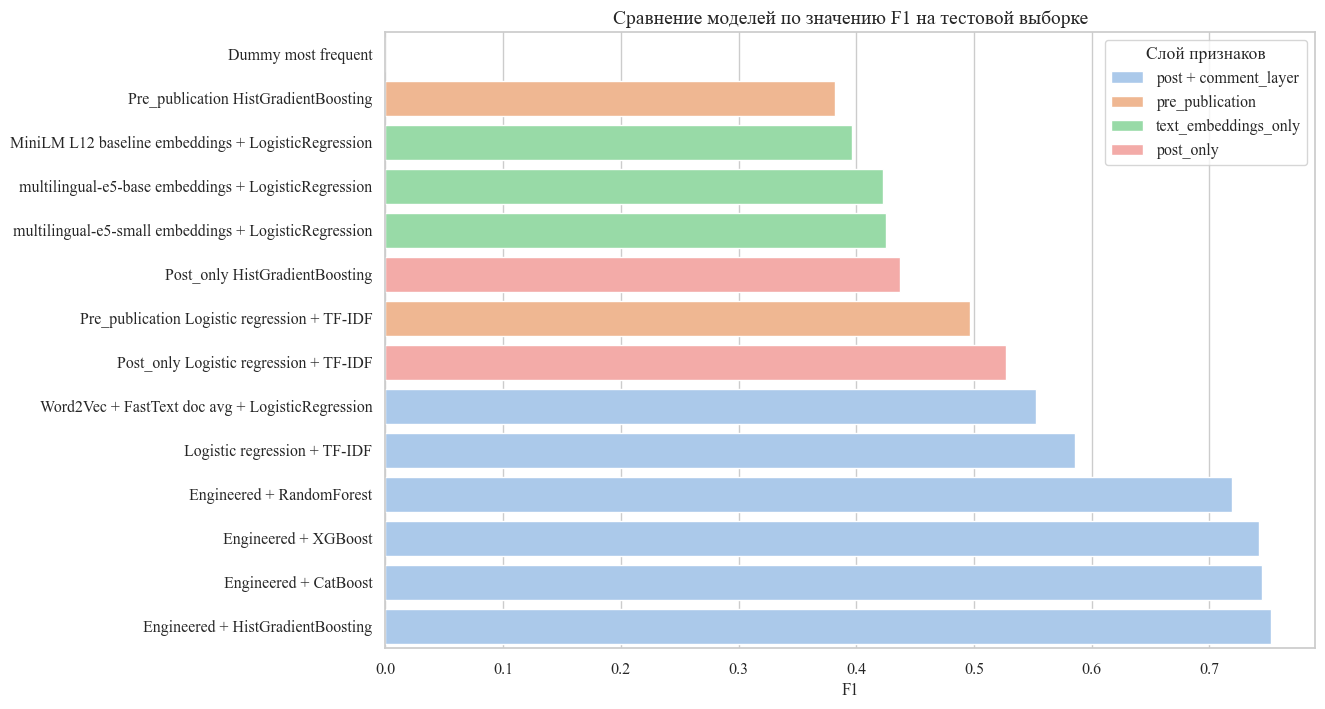

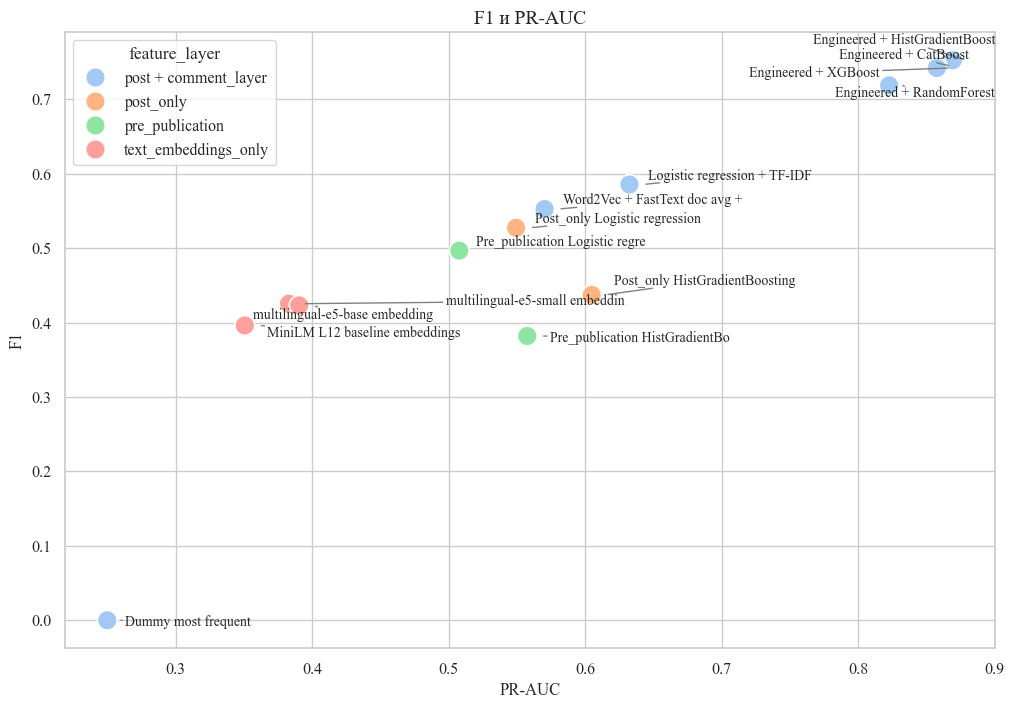

In [33]:
compare_cols = ['model', 'model_family', 'target', 'sample_size', 'target_threshold',
                'train_accuracy', 'test_accuracy', 'train_balanced_accuracy',
                'test_balanced_accuracy', 'train_F1', 'test_F1', 'test_precision',
                'test_recall', 'train_roc_auc', 'test_roc_auc', 'test_pr_auc', 'overfit_F1_gap',
                'embedding_model', 'embedding_dim', 'embeddings_seconds', 'embedding_max_length', 'embedding_batch_size',
                'feature_layer']

comparison_parts = [
    metrics.assign(feature_layer='post + comment_layer'),
    metrics_post_only.assign(feature_layer='post_only'),
    metrics_pre_publication.assign(feature_layer='pre_publication'),
    transformer_metrics.assign(feature_layer='text_embeddings_only')
]

parts = [part[[col for col in compare_cols if col in part.columns]] for part in comparison_parts]

compare = pd.concat(parts, axis=0, ignore_index=True).sort_values(
    ['test_F1', 'test_pr_auc', 'test_roc_auc'], ascending=False)

display(Markdown(f'''Данная таблица объединяет диагностические модели со слоем комментариев, модели без комментарийного слоя,
строгий вариант `pre_publication`, статичные эмбеддинги и современные multilingual embeddings.  
Лучшее значение F1 в общей таблице показывает – **{compare.iloc[0]['model']}**.  
Test_F1 = **{compare.iloc[0]['test_F1']:.2f}**.  
PR-AUC = **{compare.iloc[0]['test_pr_auc']:.2f}**.  
ROC-AUC = **{compare.iloc[0]['test_roc_auc']:.2f}**.  
  
  Это общее сравнение не означает, что все модели отвечают на один и тот же вопрос. Модели `post + comment_layer`
  имеют преимущество за счет уже наблюдаемого слоя комментариев и используются как диагностические. Более строгая
  прогнозная постановка представлена уровнем `pre_publication`.
  '''))

display(compare)

plt.figure(figsize=(12,8))
sns.barplot(data=compare.sort_values('test_F1'),
           y='model',
           x='test_F1',
           hue='feature_layer',
           dodge=False)
plt.title('Сравнение моделей по значению F1 на тестовой выборке')
plt.xlabel('F1')
plt.ylabel('')
plt.legend(title='Слой признаков', loc='upper right')
plt.show()

plt.figure(figsize=(12,8))
sns.scatterplot(data=compare,
               y='test_F1',
               x='test_pr_auc',
               hue='feature_layer',
               s=200)
texts = []
for _, row in compare.iterrows():
    texts.append(plt.text(row['test_pr_auc']+0.01, row['test_F1'],
                          str(row['model'])[:30], fontsize=10,
                         ha='left', va='center'))
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray'))
plt.title('F1 и PR-AUC')
plt.xlabel('PR-AUC')
plt.ylabel('F1')
plt.show()


Сравнение моделей показывает, что современные E5 улучшают результат относительно MiniLM, но не превосходят модели на интерпретируемых признаках. При этом все результаты нужно читать с учетом слоя признаков: модели `post + comment_layer` являются диагностическими, `post_only` исключает комментарии, а `pre_publication` является наиболее строгой прогнозной постановкой без комментариев и просмотров. Это сообщает о том, что высокий содержательный отклик в комментариях не сводится к общей семантике текста публикации: существенную роль играют нарративная рамка, источник публикации, постпубликационные метаданные и уже возникший комментарийный слой.


### Семантическая проверка смешанного нарративного класса

В данном разделе проверяется, как смешанный класс расположен между полюсами престижности и доступности.  
Тексты публикаций представляются в виде эмбеддингов multilingual-e5-small, затем рассчитывается близость каждой публикации к усредненному вектору классов Престижность и Доступность

,narrative_class,n_posts,prestige_sim_mean,access_sim_mean,access_minus_prestige_mean,access_minus_prestige_median
2,Престижность,31419,0.90,0.90,-0.01,-0.01
3,Смешанный: престижность и доступность,22879,0.91,0.90,-0.00,-0.00
1,Другое,25390,0.90,0.90,0.00,0.00
0,Доступность,12324,0.90,0.91,0.01,0.01


,mixed_sem_tendency,share
0,balanced_mixed,0.99
1,closer_to_access,0.00
2,closer_to_prestige,0.00


,post_id,source_nickname,narrative_class,prestige_similarity,access_similarity,access_minus_prestige,mixed_sem_tendency,text_clean
97806,99985,reu.csv,Смешанный: престижность и доступность,0.88,0.91,0.03,closer_to_access,собираешься в магистратуру но не знаешь с чего начать мы уже связались с приемной комиссией и все узнали за тебя а если остались вопросы ты можешь...
61158,34167,stankin.csv,Смешанный: престижность и доступность,0.90,0.92,0.02,closer_to_access,много вопросов по поступлению обсудим абитуриент приемная комиссия мгту станкин приглашает тебя на индивидуальные консультации они проходят ежедне...
24799,28171,bmstu.csv,Смешанный: престижность и доступность,0.89,0.91,0.02,closer_to_access,при подаче документов онлайн приходится самостоятельно разбираться со всеми формами документами и информацией в них чтобы ответить на вопрос как з...
94849,46549,mgpu.csv,Смешанный: престижность и доступность,0.90,0.92,0.02,closer_to_access,до какого числа нужно успеть подать документы а когда будут рейтинги сколько у меня времени чтобы принести согласие о зачислении так много вопросо...
16836,52327,ranepa.csv,Смешанный: престижность и доступность,0.89,0.91,0.02,closer_to_access,на старт внимание приемная кампания сегодня в президентской академии началась долгожданная приемная кампания- наши эксперты и волонтеры с нетерпен...
29818,50881,fa.csv,Смешанный: престижность и доступность,0.88,0.91,0.02,closer_to_access,консультация по вступительным испытаниям в бакалавриат июля в в дистанционном формате состоится консультация по вопросам вступительных испытаний н...
77294,7235,madi.csv,Смешанный: престижность и доступность,0.86,0.88,0.02,closer_to_access,подать оригинал в мади - легко оригинал документа об образовании можно подать только в один вуз до августа - для поступающих на общих основаниях м...
22257,24181,misis.csv,Смешанный: престижность и доступность,0.90,0.92,0.02,closer_to_access,изданы приказы о зачислении на бюджетные места до заполнения конкурсных мест но что делать если до зачисления не хватило совсем немного как быть с...
60869,37897,stankin.csv,Смешанный: престижность и доступность,0.89,0.92,0.02,closer_to_access,родителям абитуриентов приглашаем вас на первое в этом году родительское собрание которое пройдет января в в онлайн формате в этом году есть важны...
98625,77810,reu.csv,Смешанный: престижность и доступность,0.89,0.91,0.02,closer_to_access,привет абитуриент приемная комиссия это место где ты начинаешь строить свою карьеру с момента подачи документов задумался или уже знаешь на каком ...


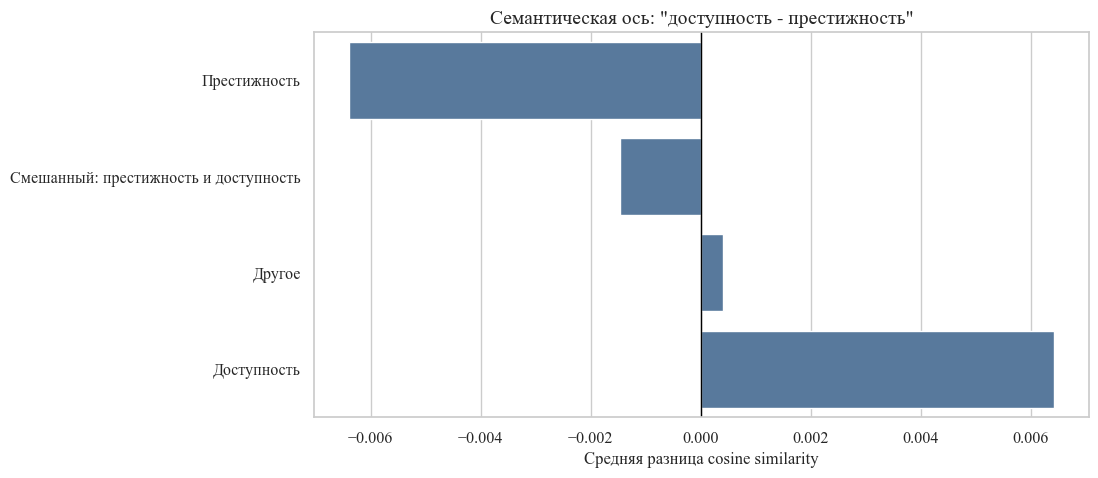

In [34]:
sem_model = 'intfloat/multilingual-e5-small'

sem_embeddings, sem_device = encode_embeddings(sem_model,
                                ml['text_clean'],
                                prefix='passage: ',
                                batch_size=32,
                                max_length=256,
                                trust_remote_code=False)

sem_embeddings = np.nan_to_num(sem_embeddings.astype('float32'),
                            nan=0,
                            posinf=0,
                            neginf=0)

prestige = ml['narrative_class'].eq('Престижность')
access = ml['narrative_class'].eq('Доступность')
mixed = ml['narrative_class'].eq('Смешанный: престижность и доступность')

prestige_proto = sem_embeddings[prestige].mean(axis=0)
prestige_proto = prestige_proto /max(np.linalg.norm(prestige_proto), 1e-9)

access_proto = sem_embeddings[access].mean(axis=0)
access_proto = access_proto /max(np.linalg.norm(access_proto), 1e-9)

ml['prestige_similarity'] = sem_embeddings @prestige_proto
ml['access_similarity'] = sem_embeddings @access_proto
ml['access_minus_prestige'] = ml['access_similarity'] - ml['prestige_similarity']

ml['mixed_sem_tendency'] = np.nan
ml.loc[mixed, 'mixed_sem_tendency'] = np.select(
    [ml.loc[mixed, 'access_minus_prestige'] > 0.02,
     ml.loc[mixed, 'access_minus_prestige'] < -0.02],
    ['closer_to_access','closer_to_prestige'],default='balanced_mixed')

sem_summary = (ml.groupby('narrative_class').agg(n_posts=('post_id', 'size'),
          prestige_sim_mean=('prestige_similarity', 'mean'),
          access_sim_mean=('access_similarity', 'mean'),
          access_minus_prestige_mean=('access_minus_prestige', 'mean'),
          access_minus_prestige_median=('access_minus_prestige', 'median'))
      .reset_index().sort_values('access_minus_prestige_mean'))

display(sem_summary)

mixed_tendency = (ml.loc[mixed, 'mixed_sem_tendency'].value_counts(normalize=True)
      .rename_axis('mixed_sem_tendency').reset_index(name='share'))

display(mixed_tendency)

display(ml.loc[mixed,['post_id',
                      'source_nickname',
                      'narrative_class',
                      'prestige_similarity',
                      'access_similarity',
                      'access_minus_prestige',
                      'mixed_sem_tendency',
                      'text_clean']].sort_values('access_minus_prestige', ascending=False).head(10))

plt.figure(figsize=(10, 5))
sns.barplot(data=sem_summary, y='narrative_class', x='access_minus_prestige_mean', color='#4C78A8')
plt.axvline(0, color='black', linewidth=1)
plt.title('Семантическая ось: "доступность - престижность"')
plt.xlabel('Средняя разница cosine similarity')
plt.ylabel('')
plt.show()

Все средние значения близости около 0.9, поскольку все тексты одного формата – поступление, университеты, обучение, приемная кампания, достижения – модель видит их как семантически похожие.  
Если посмотреть на разницу `access_minus_prestige_mean`, то направление выходит довольно логичным:  
– Престижность (-0.01) – ближе к прототипу престижности
– Доступность (+0.01) – ближе к прототипу доступности
– Смешанный (~0) – между двумя полюсами
– Другое (~0) – соответственно, ни к одному, ни к другому полюсу не относится  

  Смешанный класс таким образом занимает промежуточное положение между престижностью и доступностью, публикации в нем одновременно похожи и на то, и на то – это зона пересечения двух рамок, а не самостоятельная категория.  


## Выводы этапа  
  1. Продвинутые модели подтвердили, что высокий содержательный отклик в комментариях можно описывать лучше, чем это происходит в базовом подходе. Однако результаты нужно разделять по типу постановки: диагностическая модель со слоем комментариев, модель без комментариев и строгая pre-publication модель отвечают на разные исследовательские вопросы.
  2. Лучшее качество по F1 показывает вариант `post + comment_layer`, где используются инженерные признаки публикации, источника, нарратива, просмотров и слоя комментариев. Этот результат нельзя интерпретировать как прогноз до публикации, потому что признаки комментариев частично связаны с самой целевой переменной `meaningful_comm_clean`.
  3. Модель `post + comment_layer` остается полезной как объяснительная и диагностическая: она показывает, какие характеристики уже наблюдаемого обсуждения связаны с высоким содержательным откликом аудитории.
  4. Вариант `post_only` исключает комментарийный слой и поэтому является более строгим сравнением, но он все еще может использовать постпубликационные метаданные, например просмотры. Поэтому его корректнее понимать как модель без комментариев, а не как полностью до-публикационный прогноз.
  5. Для наиболее строгой прогнозной постановки добавлен вариант `pre_publication`, где исключены и комментарийные признаки, и просмотры. В нем остаются только текст публикации, источник, календарные признаки, нарративная рамка и тональность. Более низкое качество этой модели является ожидаемым: из нее убраны признаки уже возникшего пользовательского отклика.
  6. XGBoost и CatBoost показывают близкое качество к HistGradientBoosting в диагностической постановке. Их результаты полезны для проверки устойчивости, но содержательно важнее не выбрать “самую сложную” модель, а показать, какие слои данных дают прирост качества.
  7. Статичные эмбеддинги Word2Vec/FastText и TF-IDF уступают бустинг-моделям на инженерных признаках в диагностической постановке. Это говорит о том, что для данной задачи простого представления текста как набора слов или усредненных векторов недостаточно: важны сконструированные признаки публикации и реакции аудитории.
  8. Сравнение мультиязычных эмбеддингов MiniLM и E5 показало, что E5 улучшает результат относительно MiniLM, но не превосходит модели на интерпретируемых признаках. Следовательно, высокий содержательный отклик не сводится к общей семантике текста поста.
  9. Нарративы престижности и социальной доступности высшего образования можно анализировать не только как содержательные рамки репрезентации вузов в медиапространстве, но и как элементы коммуникации, по-разному связанные с откликом аудитории. Этот вывод усиливается сравнением моделей: качество классификации высокого содержательного отклика меняется в зависимости от того, учитываются ли только признаки публикации, постпубликационные метаданные или уже наблюдаемый комментарийный слой.
  10. Содержательный отклик в комментариях следует интерпретировать как результат взаимодействия медианарратива, формата публикации, источника сообщения и реакции аудитории, но без причинно-следственных утверждений. Работа показывает устойчивые ассоциации между признаками публикаций, нарративными рамками и комментарийным откликом.
  11. Результаты моделей нужно интерпретировать с учетом ручной валидации автоматической разметки. Ручная проверка показала, что словарные правила и признаки комментариев работают как weak labelling: они позволяют масштабировать анализ на большой корпус публикаций, но не являются точной экспертной классификацией каждого наблюдения.
